### Load and parse part of dataset for use in LTR. 

In [4]:
import pyarrow.feather as feather
import pyarrow as pa
import glob

FEATHER_DIR = "../../baidu_ultr_dataset/parts"

# ---------------------------------------------------------
# Get complete list of columns from the first feather file
# ---------------------------------------------------------
sample_file = sorted(glob.glob(f"{FEATHER_DIR}/part-*.feather"))[0]
sample_table = feather.read_table(sample_file)

# Remove ONLY the embedding column
columns = [c for c in sample_table.column_names if c != "query_document_embedding"]

# ---------------------------------------------------------
# Load all files with the filtered column list
# ---------------------------------------------------------
paths = sorted(glob.glob(f"{FEATHER_DIR}/part-*.feather"))
# remove all with part-0 in the name
paths = [p for p in paths if "part-0" in p]

tables = []
for path in paths:
    print("Loading:", path)
    table = feather.read_table(path, columns=columns)  # all except embedding
    tables.append(table)

# Merge into a single big arrow table
ltr_table = pa.concat_tables(tables, promote=True)

print(ltr_table)

Loading: ../../baidu_ultr_dataset/parts/part-0_split-0.feather
Loading: ../../baidu_ultr_dataset/parts/part-0_split-1.feather
Loading: ../../baidu_ultr_dataset/parts/part-0_split-2.feather
Loading: ../../baidu_ultr_dataset/parts/part-0_split-3.feather
Loading: ../../baidu_ultr_dataset/parts/part-0_split-4.feather
Loading: ../../baidu_ultr_dataset/parts/part-0_split-5.feather
Loading: ../../baidu_ultr_dataset/parts/part-0_split-6.feather
Loading: ../../baidu_ultr_dataset/parts/part-0_split-7.feather
Loading: ../../baidu_ultr_dataset/parts/part-0_split-8.feather
Loading: ../../baidu_ultr_dataset/parts/part-0_split-9.feather
pyarrow.Table
query_no: int64
query_id: string
query_md5: string
url_md5: string
text_md5: string
query: list<item: int64>
  child 0, item: int64
title: list<item: int64>
  child 0, item: int64
abstract: list<item: int64>
  child 0, item: int64
position: int64
media_type: int64
displayed_time: double
serp_height: int64
slipoff_count_after_click: int64
click: int64
bm2

/opt/homebrew/Caskroom/miniforge/base/envs/two-tower-confounding-2/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3579: FutureWarning: promote has been superseded by promote_options='default'.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [ ]:
import numpy as np
import pyarrow as pa
from typing import Tuple, List, Dict, Any

def extract_arrays(ltr_table: pa.Table) -> Dict[str, np.ndarray]:
    """Extract primary numpy arrays from arrow table."""
    query_no   = ltr_table["query_no"].to_numpy()
    positions  = ltr_table["position"].to_numpy() - 1  # zero-based
    clicks     = ltr_table["click"].to_numpy()
    query_md5  = ltr_table["query_md5"].to_numpy()
    return {"query_no": query_no, "positions": positions, "clicks": clicks, "query_md5": query_md5}

def session_boundaries(query_no: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    unique_sessions, start_idx = np.unique(query_no, return_index=True)
    end_idx = np.append(start_idx[1:], len(query_no))
    return unique_sessions, start_idx, end_idx

def build_ragged_lists(positions: np.ndarray, clicks: np.ndarray, start_idx: np.ndarray, end_idx: np.ndarray) -> Tuple[List[np.ndarray], List[np.ndarray]]:
    all_positions = [positions[s:e] for s, e in zip(start_idx, end_idx)]
    all_clicks    = [clicks[s:e]    for s, e in zip(start_idx, end_idx)]
    return all_positions, all_clicks

def compute_target_lengths(all_positions: List[np.ndarray]) -> np.ndarray:
    obs_lens = np.array([arr.size for arr in all_positions], dtype=np.int32)
    max_positions = np.array([int(arr.max()) if arr.size>0 else -1 for arr in all_positions], dtype=np.int32)
    target_lengths = np.where(obs_lens>0, max_positions + 1, 0)
    return target_lengths

def flatten_and_scatter(all_positions: List[np.ndarray], all_clicks: List[np.ndarray], target_lengths: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, int]:
    row_offsets = np.concatenate([[0], np.cumsum(target_lengths)[:-1]]).astype(np.int64)
    total_cells = int(row_offsets[-1] + target_lengths[-1]) if target_lengths.size else 0
    flat_positions = np.full(total_cells, -1, dtype=np.int32)
    flat_clicks = np.zeros(total_cells, dtype=np.int8)
    for i, (pos_arr, clk_arr) in enumerate(zip(all_positions, all_clicks)):
        L = pos_arr.size
        offset = row_offsets[i]
        if L == target_lengths[i]:
            flat_positions[offset:offset+L] = pos_arr
            flat_clicks[offset:offset+L] = clk_arr
        else:
            max_p = target_lengths[i]
            tmp_pos = np.full(max_p, -1, dtype=np.int32)
            tmp_clk = np.zeros(max_p, dtype=np.int8)
            tmp_pos[pos_arr] = pos_arr
            tmp_clk[pos_arr] = clk_arr
            flat_positions[offset:offset+max_p] = tmp_pos
            flat_clicks[offset:offset+max_p] = tmp_clk
    num_sessions = len(target_lengths)
    return flat_positions, flat_clicks, row_offsets, target_lengths

def reshape_to_padded(flat_positions: np.ndarray, flat_clicks: np.ndarray, row_offsets: np.ndarray, target_lengths: np.ndarray, num_sessions: int, max_len: int) -> Tuple[np.ndarray, np.ndarray]:
    padded_positions = np.full((num_sessions, max_len), -1, dtype=np.int32)
    padded_clicks    = np.zeros((num_sessions, max_len), dtype=np.int8)
    for i in range(num_sessions):
        L = target_lengths[i]
        if L == 0:
            continue
        L = min(target_lengths[i], max_len)
        off = row_offsets[i]
        padded_positions[i, :L] = flat_positions[off:off+L]
        padded_clicks[i, :L]    = flat_clicks[off:off+L]
    return padded_positions, padded_clicks

def build_mask(padded_positions: np.ndarray) -> np.ndarray:
    return (padded_positions >= 0).astype(np.int8)

def sessions_per_query_from_md5(query_md5: np.ndarray, start_idx: np.ndarray, end_idx: np.ndarray) -> np.ndarray:
    if len(start_idx) == 0:
        return np.zeros(0, dtype=np.int32)
    session_query_md5 = np.array([query_md5[s:e][0] for s, e in zip(start_idx, end_idx)])
    unique_queries, query_counts = np.unique(session_query_md5, return_counts=True)
    query_to_count = dict(zip(unique_queries, query_counts))
    sessions_per_query = np.array([query_to_count[q] for q in session_query_md5], dtype=np.int32)
    return sessions_per_query

def sessions_per_doc_pos_matrix(padded_positions: np.ndarray, mask: np.ndarray) -> np.ndarray:
    num_sessions, max_len = padded_positions.shape
    sessions_per_doc_pos = np.zeros((num_sessions, max_len, max_len), dtype=np.int32)
    for i in range(num_sessions):
        pos = padded_positions[i]
        L = np.sum(mask[i])
        sessions_per_doc_pos[i, np.arange(L), pos[:L]] = 1
    return sessions_per_doc_pos

def extract_lp_features(ltr_table: pa.Table, padded_positions: np.ndarray, lp_feature_names: List[str]) -> np.ndarray:
    num_sessions, max_len = padded_positions.shape
    lp_features_arr = np.stack([ltr_table[name].to_numpy() for name in lp_feature_names], axis=1)  # (N_total, n_features)
    mask_valid = padded_positions.ravel() >= 0
    n_features = len(lp_feature_names)
    lp_query_doc_features = np.zeros((num_sessions, max_len, n_features), dtype=np.float32)
    lp_query_doc_features.reshape(-1, n_features)[mask_valid] = lp_features_arr
    return lp_query_doc_features

def extract_query_doc_features(ltr_table: pa.Table, padded_positions: np.ndarray, feature_names: List[str]) -> np.ndarray:
    num_sessions, max_len = padded_positions.shape
    query_features_arr = np.stack([ltr_table[name].to_numpy().astype(np.float32) for name in feature_names], axis=1)  # (N_total, n_features)
    mask_valid = padded_positions.ravel() >= 0
    n_features = len(feature_names)
    query_doc_features = np.zeros((num_sessions, max_len, n_features), dtype=np.float32)
    query_doc_features.reshape(-1, n_features)[mask_valid] = query_features_arr
    return query_doc_features

def build_all(ltr_table: pa.Table) -> Dict[str, Any]:
    MAX_LEN = 20
    # 1. Extract arrays
    positions_raw = ltr_table["position"].to_numpy() - 1
    valid_mask = positions_raw < MAX_LEN
    ltr_table = ltr_table.filter(valid_mask)
    arrs = extract_arrays(ltr_table)
    
    # 2. Session boundaries
    unique_sessions, start_idx, end_idx = session_boundaries(arrs["query_no"])
    # 3. Ragged lists
    all_positions, all_clicks = build_ragged_lists(arrs["positions"], arrs["clicks"], start_idx, end_idx)
    # 4. Target lengths
    target_lengths = compute_target_lengths(all_positions)
    num_sessions = len(all_positions)
    # 5. Flatten and scatter
    flat_positions, flat_clicks, row_offsets, target_lengths = flatten_and_scatter(all_positions, all_clicks, target_lengths)
    # 6. Reshape
    padded_positions, padded_clicks = reshape_to_padded(flat_positions, flat_clicks, row_offsets, target_lengths, num_sessions, MAX_LEN)
    # 7. Mask
    mask = build_mask(padded_positions)
    # 8. sessions_per_query
    sessions_per_query = sessions_per_query_from_md5(arrs["query_md5"], start_idx, end_idx)
    # 9. sessions_per_doc_pos
    sessions_per_doc_pos = sessions_per_doc_pos_matrix(padded_positions, mask)
    # 10. features
    lp_feature_names = ["position", "media_type", "displayed_time", "serp_height", "slipoff_count_after_click"]
    lp_query_doc_features = extract_lp_features(ltr_table, padded_positions, lp_feature_names)
    feature_names = [
        "bm25", "bm25_title", "bm25_abstract",
        "tf_idf", "tf", "idf",
        "ql_jelinek_mercer_short", "ql_jelinek_mercer_long", "ql_dirichlet",
        "query_length", "document_length", "title_length", "abstract_length"
    ]
    query_doc_features = extract_query_doc_features(ltr_table, padded_positions, feature_names)
    # 11. placeholders
    query_doc_ids = np.zeros((num_sessions, MAX_LEN), dtype=np.int64)
    labels        = padded_clicks.copy()
    n             = np.ones(num_sessions, dtype=np.int32)
    # queries = np.array([ltr_table["query"][s:e][0] for s, e in zip(start_idx, end_idx)], dtype=object)
    query_no = np.array([ltr_table["query_no"][s:e][0] for s, e in zip(start_idx, end_idx)], dtype=np.int64)
    return {
        "padded_positions": padded_positions,
        "padded_clicks": padded_clicks,
        "mask": mask,
        "sessions_per_query": sessions_per_query,
        "sessions_per_doc_pos": sessions_per_doc_pos,
        "lp_query_doc_features": lp_query_doc_features,
        "query_doc_features": query_doc_features,
        "query_doc_ids": query_doc_ids,
        "labels": labels,
        "n": n,
        "start_idx": start_idx,
        "end_idx": end_idx,
        "unique_sessions": unique_sessions,
        "queries": query_no,
    }

# Runner: call build_all and print shapes
result = build_all(ltr_table)
padded_positions = result["padded_positions"]
padded_clicks = result["padded_clicks"]
mask = result["mask"]
sessions_per_query = result["sessions_per_query"]
sessions_per_doc_pos = result["sessions_per_doc_pos"]
lp_query_doc_features = result["lp_query_doc_features"]
query_doc_features = result["query_doc_features"]
query_doc_ids = result["query_doc_ids"]
labels = result["labels"]
n = result["n"]
start_idx = result["start_idx"]
end_idx = result["end_idx"]
unique_sessions = result["unique_sessions"]
queries = result["queries"]

np.savez_compressed(
    "train_Baidu_ULTRA.npz",
    padded_positions=padded_positions,
    padded_clicks=padded_clicks,
    mask=mask,
    sessions_per_query=sessions_per_query,
    sessions_per_doc_pos=sessions_per_doc_pos,
    query_doc_features=query_doc_features,
    lp_query_doc_features=lp_query_doc_features,
    query_doc_ids=query_doc_ids,
    n=n,
    queries=queries,
    labels=labels
)

# Legacy Code: Parse multiple Bias types

In [ ]:
import glob
import pyarrow as pa
import pyarrow.feather as feather

FEATHER_DIR = "../../baidu_ultr_dataset/parts"

sample_file = sorted(glob.glob(f"{FEATHER_DIR}/part-*.feather"))[0]
sample_table = feather.read_table(sample_file)

columns = [
    c for c in sample_table.column_names
    if c != "query_document_embedding"
]

paths = sorted(glob.glob(f"{FEATHER_DIR}/part-*.feather"))
paths = [p for p in paths if "part-3" not in p]

tables = []

for path in paths:
    print("Loading:", path)
    table = feather.read_table(path, columns=columns)
    part_col = pa.array([path] * table.num_rows, type=pa.string())
    table = table.append_column("part", part_col)
    tables.append(table)

ltr_table = pa.concat_tables(tables, promote=True)

print(ltr_table)


Loading: ../baidu_ultr_dataset/parts/part-0_split-0.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-1.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-2.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-3.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-4.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-5.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-6.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-7.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-8.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-9.feather
Loading: ../baidu_ultr_dataset/parts/part-1_split-0.feather
Loading: ../baidu_ultr_dataset/parts/part-1_split-1.feather
Loading: ../baidu_ultr_dataset/parts/part-1_split-2.feather
Loading: ../baidu_ultr_dataset/parts/part-1_split-3.feather
Loading: ../baidu_ultr_dataset/parts/part-1_split-4.feather
Loading: ../baidu_ultr_dataset/parts/part-1_split-5.feather
Loading: ../baidu_ultr_dataset/parts/par

/opt/homebrew/Caskroom/miniforge/base/envs/two-tower-confounding-2/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3579: FutureWarning: promote has been superseded by promote_options='default'.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [46]:
def rank_bin_feature_index(array: pa.ChunkedArray, num_bins: int = 10):
    """
    Perform rank-based binning on a PyArrow ChunkedArray.
    Returns the bin indices (integers) and the bin edges (for reference).
    Ensures no empty bins.
    """
    values = array.to_numpy()
    N = len(values)
    
    # Step 1: sort indices by value
    sorted_idx = np.argsort(values)
    
    # Step 2: assign bins based on rank
    bins = np.zeros(N, dtype=int)
    for i in range(num_bins):
        start = i * N // num_bins
        end = (i + 1) * N // num_bins
        bins[sorted_idx[start:end]] = i
    
    # Step 3: create edges for reference (optional)
    edges = [values[sorted_idx[i * N // num_bins]] for i in range(num_bins)]
    edges.append(values[sorted_idx[-1]])  # max value
    
    # Step 4: return as PyArrow int32 array
    binned_indices = pa.array(bins, type=pa.int32())
    return binned_indices, edges

# Example usage for multiple features
features = ["displayed_time", "serp_height", "slipoff_count_after_click"]
bin_edges_map = {}
new_columns = {}

for feat in features:
    col = ltr_table[feat].combine_chunks()
    binned_col, edges = rank_bin_feature_index(col, num_bins=10)
    new_columns[feat] = binned_col
    bin_edges_map[feat] = edges


# Add new columns to the table
for name, column in new_columns.items():
    ltr_table = ltr_table.remove_column(ltr_table.schema.get_field_index(name))
    ltr_table = ltr_table.append_column(name, column)


def map_to_zero_based(array: pa.ChunkedArray):
    values = array.to_numpy()
    unique_vals = np.unique(values)
    val_to_idx = {v: i for i, v in enumerate(unique_vals)}
    mapped_values = np.array([val_to_idx[v] for v in values], dtype=np.int32)
    return pa.array(mapped_values, type=pa.int32()), unique_vals

# Example usage
binned_col_media_type, unique_vals_media_type = map_to_zero_based(ltr_table["media_type"].combine_chunks())
ltr_table = ltr_table.remove_column(ltr_table.schema.get_field_index("media_type"))
ltr_table = ltr_table.append_column("media_type", binned_col_media_type)

binned_col, unique_vals = map_to_zero_based(ltr_table["position"].combine_chunks())
ltr_table = ltr_table.remove_column(ltr_table.schema.get_field_index("position"))
ltr_table = ltr_table.append_column("position", binned_col)


position_col = ltr_table["position"].to_numpy()

# Create a boolean mask for positions <= 19
mask = position_col <= 19

# Apply the mask to filter the table
ltr_table = ltr_table.filter(mask)

print("Converted unique values:")
print(len(np.unique(ltr_table["displayed_time"].to_numpy())))
print(len(np.unique(ltr_table["serp_height"].to_numpy())))
print(len(np.unique(ltr_table["slipoff_count_after_click"].to_numpy())))
print(len(np.unique(ltr_table["position"].to_numpy())))
print(len(np.unique(ltr_table["media_type"].to_numpy())))
lp_feature_names = ["position", "media_type", "displayed_time", "serp_height", "slipoff_count_after_click"]
unique_list = [len(np.unique(ltr_table[name].to_numpy())) for name in lp_feature_names]
print("Unique list:", unique_list)

Converted unique values:
10
10
10
20
613
Unique list: [20, 613, 10, 10, 10]


In [66]:
import pyarrow.compute as pc
import numpy as np
mask_part0 = pc.match_substring(ltr_table["part"], "part-1")
train = ltr_table.filter(mask_part0)
rest = ltr_table.filter(pc.invert(mask_part0))
mask_part1 = pc.match_substring(rest["part"], "part-2")
val = rest.filter(mask_part1)
test = rest.filter(pc.invert(mask_part1))

# print the unique parts in each split
print("Train parts:", train["part"].unique().to_pylist())
print("Val parts:", val["part"].unique().to_pylist())
print("Test parts:", test["part"].unique().to_pylist())

Train parts: ['../baidu_ultr_dataset/parts/part-1_split-0.feather', '../baidu_ultr_dataset/parts/part-1_split-1.feather', '../baidu_ultr_dataset/parts/part-1_split-2.feather', '../baidu_ultr_dataset/parts/part-1_split-3.feather', '../baidu_ultr_dataset/parts/part-1_split-4.feather', '../baidu_ultr_dataset/parts/part-1_split-5.feather', '../baidu_ultr_dataset/parts/part-1_split-6.feather', '../baidu_ultr_dataset/parts/part-1_split-7.feather', '../baidu_ultr_dataset/parts/part-1_split-8.feather', '../baidu_ultr_dataset/parts/part-1_split-9.feather']
Val parts: ['../baidu_ultr_dataset/parts/part-2_split-0.feather', '../baidu_ultr_dataset/parts/part-2_split-1.feather', '../baidu_ultr_dataset/parts/part-2_split-2.feather', '../baidu_ultr_dataset/parts/part-2_split-3.feather', '../baidu_ultr_dataset/parts/part-2_split-4.feather', '../baidu_ultr_dataset/parts/part-2_split-5.feather', '../baidu_ultr_dataset/parts/part-2_split-6.feather', '../baidu_ultr_dataset/parts/part-2_split-7.feather', '.

In [ ]:
position_col = test["position"].to_numpy()
queries_col = test["query_no"].to_numpy()  # ensure this is numpy, not PyArrow string array

# Find all queries that have at least one position == 12
queries_with_pos12 = np.unique(queries_col[position_col >= 12])
mask = np.isin(queries_col, queries_with_pos12)
test_position_outliers = test.filter(mask)

media_col = test["media_type"].to_numpy()
unique_vals, val_counts = np.unique(media_col, return_counts=True)
keep_vals = unique_vals[val_counts >= 100_000]
mask = np.isin(media_col, keep_vals)
test_media_type_outliers = test.filter(mask)

In [ ]:
import numpy as np
import pyarrow as pa
from typing import Tuple, List, Dict, Any

def extract_arrays(ltr_table: pa.Table) -> Dict[str, np.ndarray]:
    """Extract primary numpy arrays from arrow table."""
    query_no   = ltr_table["query_no"].to_numpy()
    positions  = ltr_table["position"].to_numpy()  # zero-based
    clicks     = ltr_table["click"].to_numpy()
    query_md5  = ltr_table["query_md5"].to_numpy()
    return {"query_no": query_no, "positions": positions, "clicks": clicks, "query_md5": query_md5}

def session_boundaries(query_no: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    unique_sessions, start_idx = np.unique(query_no, return_index=True)
    end_idx = np.append(start_idx[1:], len(query_no))
    return unique_sessions, start_idx, end_idx

def build_ragged_lists(positions: np.ndarray, clicks: np.ndarray, start_idx: np.ndarray, end_idx: np.ndarray) -> Tuple[List[np.ndarray], List[np.ndarray]]:
    all_positions = [positions[s:e] for s, e in zip(start_idx, end_idx)]
    all_clicks    = [clicks[s:e]    for s, e in zip(start_idx, end_idx)]
    return all_positions, all_clicks

def compute_target_lengths(all_positions: List[np.ndarray]) -> np.ndarray:
    obs_lens = np.array([arr.size for arr in all_positions], dtype=np.int32)
    max_positions = np.array([int(arr.max()) if arr.size>0 else -1 for arr in all_positions], dtype=np.int32)
    target_lengths = np.where(obs_lens>0, max_positions + 1, 0)
    return target_lengths

def flatten_and_scatter(all_positions: List[np.ndarray], all_clicks: List[np.ndarray], target_lengths: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, int]:
    row_offsets = np.concatenate([[0], np.cumsum(target_lengths)[:-1]]).astype(np.int64)
    total_cells = int(row_offsets[-1] + target_lengths[-1]) if target_lengths.size else 0
    flat_positions = np.full(total_cells, -1, dtype=np.int32)
    flat_clicks = np.zeros(total_cells, dtype=np.int8)
    for i, (pos_arr, clk_arr) in enumerate(zip(all_positions, all_clicks)):
        L = pos_arr.size
        offset = row_offsets[i]
        if L == target_lengths[i]:
            flat_positions[offset:offset+L] = pos_arr
            flat_clicks[offset:offset+L] = clk_arr
        else:
            max_p = target_lengths[i]
            tmp_pos = np.full(max_p, -1, dtype=np.int32)
            tmp_clk = np.zeros(max_p, dtype=np.int8)
            tmp_pos[pos_arr] = pos_arr
            tmp_clk[pos_arr] = clk_arr
            flat_positions[offset:offset+max_p] = tmp_pos
            flat_clicks[offset:offset+max_p] = tmp_clk
    num_sessions = len(target_lengths)
    return flat_positions, flat_clicks, row_offsets, target_lengths

def reshape_to_padded(flat_positions: np.ndarray, flat_clicks: np.ndarray, row_offsets: np.ndarray, target_lengths: np.ndarray, num_sessions: int, max_len: int) -> Tuple[np.ndarray, np.ndarray]:
    padded_positions = np.full((num_sessions, max_len), -1, dtype=np.int32)
    padded_clicks    = np.zeros((num_sessions, max_len), dtype=np.int8)
    for i in range(num_sessions):
        L = target_lengths[i]
        if L == 0:
            continue
        L = min(target_lengths[i], max_len)
        off = row_offsets[i]
        padded_positions[i, :L] = flat_positions[off:off+L]
        padded_clicks[i, :L]    = flat_clicks[off:off+L]
    return padded_positions, padded_clicks

def build_mask(padded_positions: np.ndarray) -> np.ndarray:
    return (padded_positions >= 0).astype(np.int8)

def sessions_per_query_from_md5(query_md5: np.ndarray, start_idx: np.ndarray, end_idx: np.ndarray) -> np.ndarray:
    if len(start_idx) == 0:
        return np.zeros(0, dtype=np.int32)
    session_query_md5 = np.array([query_md5[s:e][0] for s, e in zip(start_idx, end_idx)])
    unique_queries, query_counts = np.unique(session_query_md5, return_counts=True)
    query_to_count = dict(zip(unique_queries, query_counts))
    sessions_per_query = np.array([query_to_count[q] for q in session_query_md5], dtype=np.int32)
    return sessions_per_query

def sessions_per_doc_pos_matrix(padded_positions: np.ndarray, mask: np.ndarray) -> np.ndarray:
    num_sessions, max_len = padded_positions.shape
    sessions_per_doc_pos = np.zeros((num_sessions, max_len, max_len), dtype=np.int32)
    for i in range(num_sessions):
        pos = padded_positions[i]
        L = np.sum(mask[i])
        sessions_per_doc_pos[i, np.arange(L), pos[:L]] = 1
    return sessions_per_doc_pos

def extract_lp_features(ltr_table: pa.Table, padded_positions: np.ndarray, lp_feature_names: List[str]) -> np.ndarray:
    num_sessions, max_len = padded_positions.shape
    lp_features_arr = np.stack([ltr_table[name].to_numpy() for name in lp_feature_names], axis=1)  # (N_total, n_features)
    
    mask_valid = padded_positions.ravel() >= 0
    n_features = len(lp_feature_names)
    lp_query_doc_features = np.zeros((num_sessions, max_len, n_features), dtype=np.float32)

    lp_query_doc_features.reshape(-1, n_features)[mask_valid] = lp_features_arr
    # convert all features to integer
    lp_query_doc_features = lp_query_doc_features.astype(np.int32)
    return lp_query_doc_features

def extract_query_doc_features(ltr_table: pa.Table, padded_positions: np.ndarray, feature_names: List[str]) -> np.ndarray:
    num_sessions, max_len = padded_positions.shape
    query_features_arr = np.stack([ltr_table[name].to_numpy().astype(np.float32) for name in feature_names], axis=1)  # (N_total, n_features)
    mask_valid = padded_positions.ravel() >= 0
    n_features = len(feature_names)
    query_doc_features = np.zeros((num_sessions, max_len, n_features), dtype=np.float32)
    query_doc_features.reshape(-1, n_features)[mask_valid] = query_features_arr
    return query_doc_features

def build_all(ltr_table: pa.Table) -> Dict[str, Any]:
    arrs = extract_arrays(ltr_table)
    MAX_LEN = 20
    # 2. Session boundaries
    unique_sessions, start_idx, end_idx = session_boundaries(arrs["query_no"])
    # 3. Ragged lists
    all_positions, all_clicks = build_ragged_lists(arrs["positions"], arrs["clicks"], start_idx, end_idx)
    # 4. Target lengths
    target_lengths = compute_target_lengths(all_positions)
    num_sessions = len(all_positions)
    # 5. Flatten and scatter
    flat_positions, flat_clicks, row_offsets, target_lengths = flatten_and_scatter(all_positions, all_clicks, target_lengths)
    # 6. Reshape
    padded_positions, padded_clicks = reshape_to_padded(flat_positions, flat_clicks, row_offsets, target_lengths, num_sessions, MAX_LEN)
    # 7. Mask
    mask = build_mask(padded_positions)
    # 8. sessions_per_query
    sessions_per_query = sessions_per_query_from_md5(arrs["query_md5"], start_idx, end_idx)
    # 9. sessions_per_doc_pos
    sessions_per_doc_pos = sessions_per_doc_pos_matrix(padded_positions, mask)
    # 10. features
    lp_feature_names = ["position", "media_type", "displayed_time", "serp_height", "slipoff_count_after_click"]
    lp_query_doc_features = extract_lp_features(ltr_table, padded_positions, lp_feature_names)
    feature_names = [
        "bm25", "bm25_title", "bm25_abstract",
        "tf_idf", "tf", "idf",
        "ql_jelinek_mercer_short", "ql_jelinek_mercer_long", "ql_dirichlet",
        "query_length", "document_length", "title_length", "abstract_length"
    ]
    query_doc_features = extract_query_doc_features(ltr_table, padded_positions, feature_names)
    # 11. placeholders
    query_doc_ids = np.zeros((num_sessions, MAX_LEN), dtype=np.int64)
    labels        = padded_clicks.copy()
    n             = np.ones(num_sessions, dtype=np.int32)
    # queries = np.array([ltr_table["query"][s:e][0] for s, e in zip(start_idx, end_idx)], dtype=object)
    query_no = np.array([ltr_table["query_no"][s:e][0] for s, e in zip(start_idx, end_idx)], dtype=np.int64)
    return {
        "padded_positions": padded_positions,
        "padded_clicks": padded_clicks,
        "mask": mask,
        "sessions_per_query": sessions_per_query,
        "sessions_per_doc_pos": sessions_per_doc_pos,
        "lp_query_doc_features": lp_query_doc_features,
        "query_doc_features": query_doc_features,
        "query_doc_ids": query_doc_ids,
        "labels": labels,
        "n": n,
        "start_idx": start_idx,
        "end_idx": end_idx,
        "unique_sessions": unique_sessions,
        "queries": query_no,
    }

# Runner: call build_all and print shapes
result = build_all(train)
padded_positions = result["padded_positions"]
padded_clicks = result["padded_clicks"]
mask = result["mask"]
sessions_per_query = result["sessions_per_query"]
sessions_per_doc_pos = result["sessions_per_doc_pos"]
lp_query_doc_features = result["lp_query_doc_features"]
query_doc_features = result["query_doc_features"]
query_doc_ids = result["query_doc_ids"]
labels = result["labels"]
n = result["n"]
start_idx = result["start_idx"]
end_idx = result["end_idx"]
unique_sessions = result["unique_sessions"]
queries = result["queries"]

In [16]:
np.savez_compressed(
    "train_Baidu_ULTRA_part1_media_type_position.npz",
    padded_positions=padded_positions,
    padded_clicks=padded_clicks,
    mask=mask,
    sessions_per_query=sessions_per_query,
    sessions_per_doc_pos=sessions_per_doc_pos,
    query_doc_features=query_doc_features,
    lp_query_doc_features=lp_query_doc_features,
    query_doc_ids=query_doc_ids,
    n=n,
    queries=queries,
    labels=labels,
    unique_list=unique_list
)

In [17]:
result = build_all(val)
padded_positions = result["padded_positions"]
padded_clicks = result["padded_clicks"]
mask = result["mask"]
sessions_per_query = result["sessions_per_query"]
sessions_per_doc_pos = result["sessions_per_doc_pos"]
lp_query_doc_features = result["lp_query_doc_features"]
query_doc_features = result["query_doc_features"]
query_doc_ids = result["query_doc_ids"]
labels = result["labels"]
n = result["n"]
start_idx = result["start_idx"]
end_idx = result["end_idx"]
unique_sessions = result["unique_sessions"]
queries = result["queries"]

In [18]:
np.savez_compressed(
    "val_Baidu_ULTRA_part1_media_type_position.npz",
    padded_positions=padded_positions,
    padded_clicks=padded_clicks,
    mask=mask,
    sessions_per_query=sessions_per_query,
    sessions_per_doc_pos=sessions_per_doc_pos,
    query_doc_features=query_doc_features,
    lp_query_doc_features=lp_query_doc_features,
    query_doc_ids=query_doc_ids,
    n=n,
    queries=queries,
    labels=labels,
    unique_list=unique_list
)

In [19]:
result = build_all(test)
padded_positions = result["padded_positions"]
padded_clicks = result["padded_clicks"]
mask = result["mask"]
sessions_per_query = result["sessions_per_query"]
sessions_per_doc_pos = result["sessions_per_doc_pos"]
lp_query_doc_features = result["lp_query_doc_features"]
query_doc_features = result["query_doc_features"]
query_doc_ids = result["query_doc_ids"]
labels = result["labels"]
n = result["n"]
start_idx = result["start_idx"]
end_idx = result["end_idx"]
unique_sessions = result["unique_sessions"]
queries = result["queries"]

In [20]:
np.savez_compressed(
    "test_Baidu_ULTRA_part1_media_type_position.npz",
    padded_positions=padded_positions,
    padded_clicks=padded_clicks,
    mask=mask,
    sessions_per_query=sessions_per_query,
    sessions_per_doc_pos=sessions_per_doc_pos,
    query_doc_features=query_doc_features,
    lp_query_doc_features=lp_query_doc_features,
    query_doc_ids=query_doc_ids,
    n=n,
    queries=queries,
    labels=labels,
    unique_list=unique_list
)

In [76]:
result = build_all(test_media_type_outliers)
padded_positions = result["padded_positions"]
padded_clicks = result["padded_clicks"]
mask = result["mask"]
sessions_per_query = result["sessions_per_query"]
sessions_per_doc_pos = result["sessions_per_doc_pos"]
lp_query_doc_features = result["lp_query_doc_features"]
query_doc_features = result["query_doc_features"]
query_doc_ids = result["query_doc_ids"]
labels = result["labels"]
n = result["n"]
start_idx = result["start_idx"]
end_idx = result["end_idx"]
unique_sessions = result["unique_sessions"]
queries = result["queries"]

np.savez_compressed(
    "test_md_outliers_Baidu_ULTRA_all.npz",
    padded_positions=padded_positions,
    padded_clicks=padded_clicks,
    mask=mask,
    sessions_per_query=sessions_per_query,
    sessions_per_doc_pos=sessions_per_doc_pos,
    query_doc_features=query_doc_features,
    lp_query_doc_features=lp_query_doc_features,
    query_doc_ids=query_doc_ids,
    n=n,
    queries=queries,
    labels=labels,
    unique_list=unique_list
)

result = build_all(test_position_outliers)
padded_positions = result["padded_positions"]
padded_clicks = result["padded_clicks"]
mask = result["mask"]
sessions_per_query = result["sessions_per_query"]
sessions_per_doc_pos = result["sessions_per_doc_pos"]
lp_query_doc_features = result["lp_query_doc_features"]
query_doc_features = result["query_doc_features"]
query_doc_ids = result["query_doc_ids"]
labels = result["labels"]
n = result["n"]
start_idx = result["start_idx"]
end_idx = result["end_idx"]
unique_sessions = result["unique_sessions"]
queries = result["queries"]

np.savez_compressed(
    "test_pos_outliers_Baidu_ULTRA_all.npz",
    padded_positions=padded_positions,
    padded_clicks=padded_clicks,
    mask=mask,
    sessions_per_query=sessions_per_query,
    sessions_per_doc_pos=sessions_per_doc_pos,
    query_doc_features=query_doc_features,
    lp_query_doc_features=lp_query_doc_features,
    query_doc_ids=query_doc_ids,
    n=n,
    queries=queries,
    labels=labels,
    unique_list=unique_list
)

In [7]:
lp_query_doc_features[:, :, 0].shape

(593235, 20)

In [6]:
import os
os.listdir("..")

['new_data.ipynb',
 'Identifiability Matters Chen 2024.pdf',
 '.DS_Store',
 'two-tower-confounding',
 'Limits of Click-Based LTR Oosterhuis 2022.pdf',
 'ltr_datasets',
 'output.png',
 'analysis copy.ipynb',
 '.vscode',
 'baidu_ultr_dataset']

In [36]:
data = np.load("../ltr_datasets/test_Baidu_ULTRA_all.npz")

In [41]:
list(data.keys())

['padded_positions',
 'padded_clicks',
 'mask',
 'sessions_per_query',
 'sessions_per_doc_pos',
 'query_doc_features',
 'lp_query_doc_features',
 'query_doc_ids',
 'n',
 'queries',
 'labels',
 'unique_list']

# Load Full Train and Test sets for evaluation. 

### Evaluate if dataset loading works

In [ ]:
from two_tower_confounding.data.base import RatingDataset
from two_tower_confounding.simulation.datasets import ClickDataset

data = np.load("train_Baidu_ULTRA_part1.npz", allow_pickle=True)
padded_positions = data["padded_positions"]
mask = data["mask"]
padded_clicks = data["padded_clicks"]
sessions_per_query = data["sessions_per_query"]
sessions_per_doc_pos = data["sessions_per_doc_pos"]
query_doc_features = data["query_doc_features"]
lp_query_doc_features = data["lp_query_doc_features"]
query_doc_ids = data["query_doc_ids"]
n = data["n"]
queries = data["queries"]

rating_dataset = RatingDataset(
    query = queries,
    query_doc_ids=query_doc_ids,
    query_doc_features=query_doc_features,
    lp_query_doc_features=lp_query_doc_features,
    labels=padded_clicks,
    mask=mask,
    n=n,
)

# -----------------------------
# Construct ClickDataset
# -----------------------------
sessions = np.arange(len(rating_dataset))  # each session corresponds to a row in RatingDataset

click_dataset = ClickDataset(

    rating_dataset=rating_dataset,
    sessions=sessions,
    clicks=padded_clicks,
    positions=padded_positions,
    sessions_per_query=sessions_per_query,
    sessions_per_doc_pos=sessions_per_doc_pos,
)

print("RatingDataset.query.shape:", rating_dataset.query.shape)
print("RatingDataset.query_doc_features.shape:", rating_dataset.query_doc_features.shape)
print("RatingDataset.lp_query_doc_features.shape:", rating_dataset.lp_query_doc_features.shape)
print("ClickDataset.clicks.shape:", click_dataset.clicks.shape)
print("ClickDataset.positions.shape:", click_dataset.positions.shape)
print("ClickDataset.sessions_per_query.shape:", click_dataset.sessions_per_query.shape)
print("ClickDataset.sessions_per_doc_pos.shape:", click_dataset.sessions_per_doc_pos.shape)

RatingDataset.query.shape: (593235,)
RatingDataset.query_doc_features.shape: (593235, 20, 13)
RatingDataset.lp_query_doc_features.shape: (593235, 20, 5)
ClickDataset.clicks.shape: (593235, 20)
ClickDataset.positions.shape: (593235, 20)
ClickDataset.sessions_per_query.shape: (593235,)
ClickDataset.sessions_per_doc_pos.shape: (593235, 20, 20)


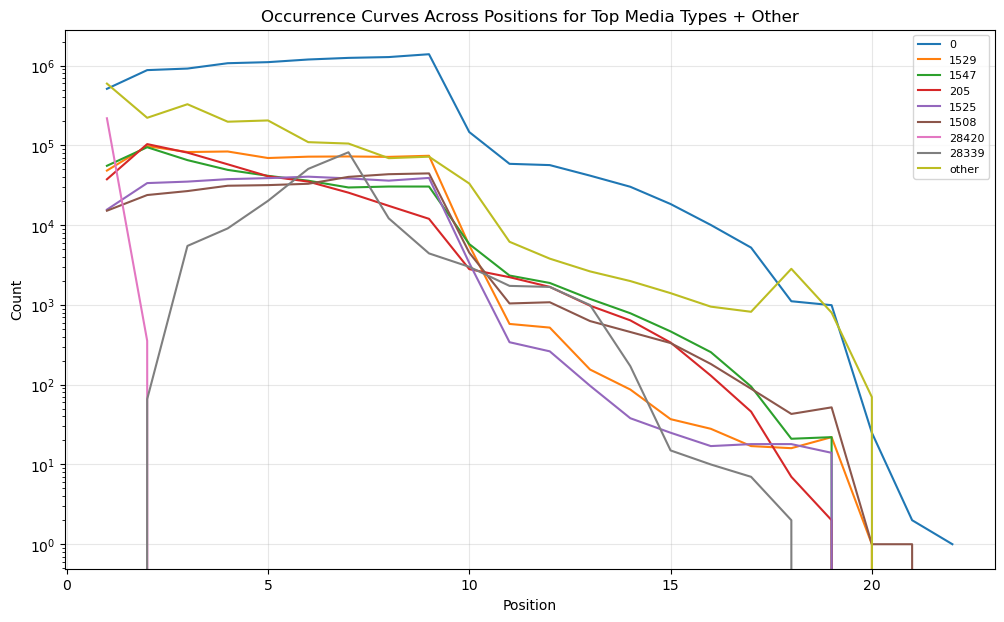

In [117]:
import numpy as np
import matplotlib.pyplot as plt

# Extract columns from pyarrow table as numpy
media_arr = ltr_table["media_type"].to_numpy()
pos_arr   = ltr_table["position"].to_numpy()

# ---- Step 1: Find top 10 media types ----
unique_vals, counts = np.unique(media_arr, return_counts=True)
top_k = 8
sorted_idx = np.argsort(counts)[::-1]
top_media = unique_vals[sorted_idx[:top_k]]
other_media = set(unique_vals) - set(top_media)

# ---- Step 2: Position domain ----
positions = np.sort(np.unique(pos_arr))

# ---- Step 3: Allocate occurrence matrix ----
media_types = list(top_media) + ["other"]
occ_matrix = {m: np.zeros(len(positions), dtype=int) for m in media_types}

# ---- Step 4: Count occurrences for each position ----
for i, pos in enumerate(positions):
    mask_pos = (pos_arr == pos)

    # media types for this position
    media_at_pos = media_arr[mask_pos]
    unique_pos_vals, pos_counts = np.unique(media_at_pos, return_counts=True)
    pos_count_map = dict(zip(unique_pos_vals, pos_counts))

    # fill top media types
    for m in top_media:
        occ_matrix[m][i] = pos_count_map.get(m, 0)

    # fill 'other'
    other_count = sum(c for m, c in pos_count_map.items() if m not in top_media)
    occ_matrix["other"][i] = other_count

# ---- Step 5: Plot curves ----
plt.figure(figsize=(12, 7))

for m in media_types:
    plt.plot(positions, occ_matrix[m], label=m)

plt.xlabel("Position")
plt.ylabel("Count")
plt.yscale("log")
plt.title("Occurrence Curves Across Positions for Top Media Types + Other")
plt.legend(loc="upper right", fontsize=8)
plt.grid(alpha=0.3)
plt.show()


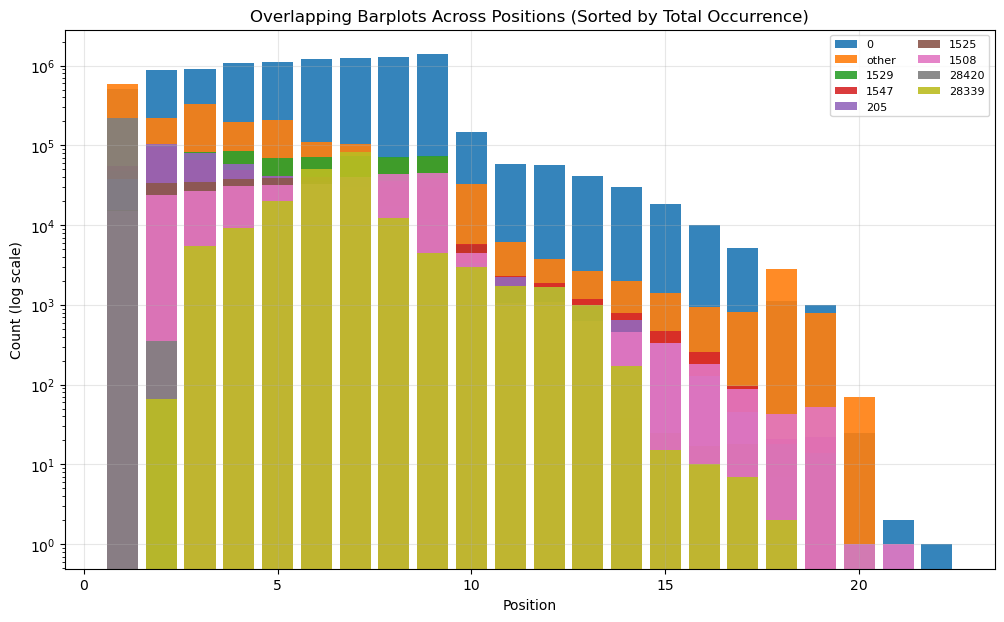

In [118]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

bar_width = 0.8
alpha = 0.9

# --- Compute total occurrences for sorting ---
total_counts = {m: occ_matrix[m].sum() for m in media_types}

# --- Sort media types by total count (descending = big bars drawn first) ---
sorted_media = sorted(media_types, key=lambda m: total_counts[m], reverse=True)

# --- Plot in sorted order ---
for m in sorted_media:
    plt.bar(
        positions,
        occ_matrix[m],
        width=bar_width,
        alpha=alpha,
        label=m
    )

plt.xlabel("Position")
plt.ylabel("Count (log scale)")
plt.title("Overlapping Barplots Across Positions (Sorted by Total Occurrence)")
plt.yscale("log")
plt.legend(loc="upper right", fontsize=8, ncol=2)
plt.grid(alpha=0.3)
plt.show()


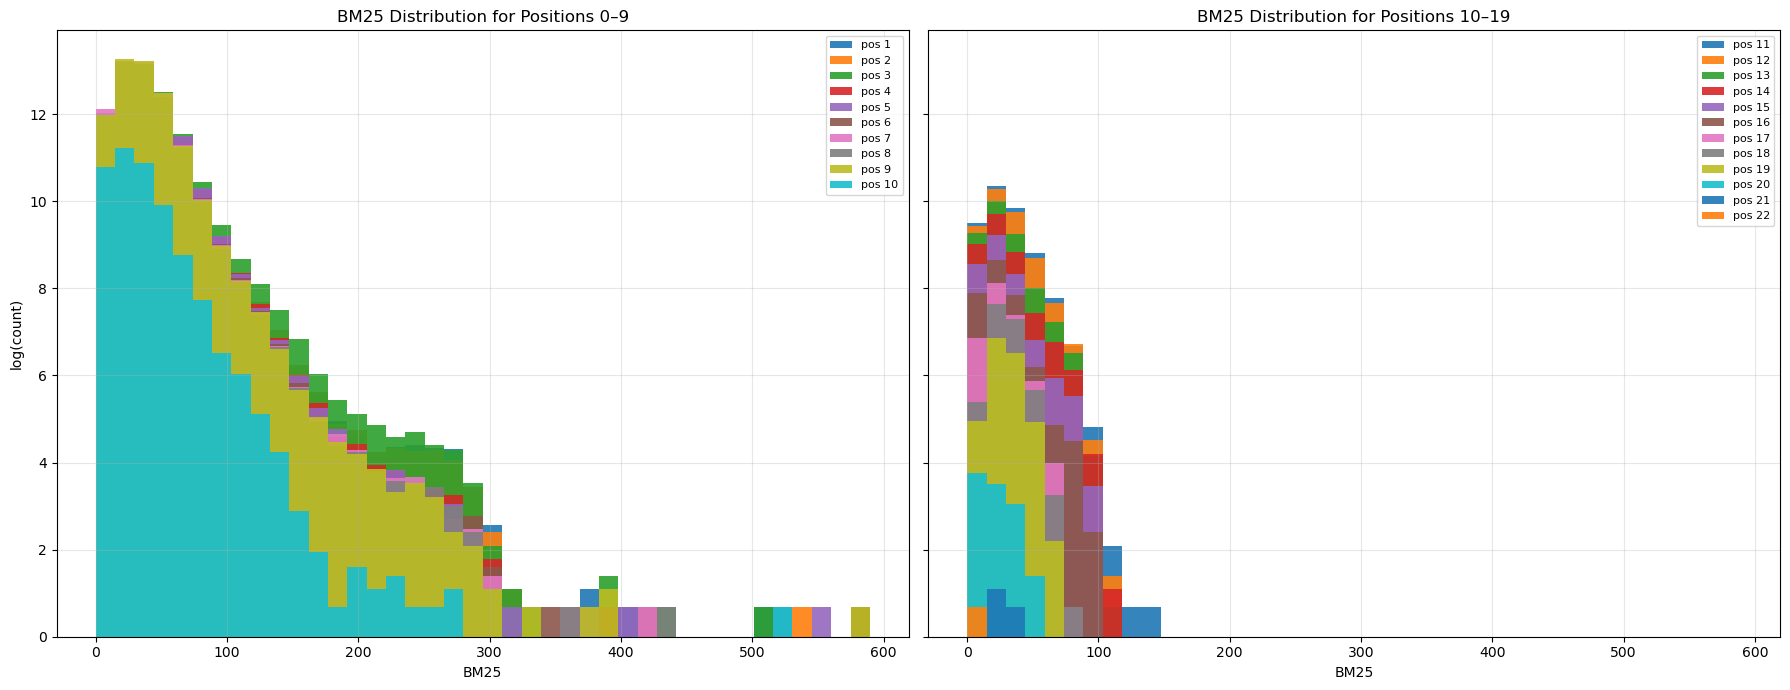

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extract columns from pyarrow table as numpy
idf_arr = ltr_table["bm25"].to_numpy()
pos_arr = ltr_table["position"].to_numpy()

# ---- Step 1: Define positions ----
positions = np.sort(np.unique(pos_arr))

# ---- Step 2: Define histogram binning ----
num_bins = 40
idf_min, idf_max = idf_arr.min(), idf_arr.max()
bins = np.linspace(idf_min, idf_max, num_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# ---- Step 3: Compute histograms per position ----
histograms = {}
for pos in positions:
    mask = pos_arr == pos
    idf_values = idf_arr[mask]

    counts, _ = np.histogram(idf_values, bins=bins)
    histograms[pos] = np.log1p(counts)  # log-counts

# ---- Step 4: Split positions into two groups ----
left_positions = positions[:10]   # first 10
right_positions = positions[10:]  # next 10

alpha = 0.9  # no transparency requested

# ---- Step 5: Two-panel plot ----
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# --- Left subplot: positions 0–9 ---
ax = axes[0]
for pos in left_positions:
    ax.bar(
        bin_centers,
        histograms[pos],
        width=(bins[1] - bins[0]),
        alpha=alpha,
        label=f"pos {pos}"
    )
ax.set_title("BM25 Distribution for Positions 0–9")
ax.set_xlabel("BM25")
ax.set_ylabel("log(count)")
ax.grid(alpha=0.3)
ax.legend(ncol=1, fontsize=8)

# --- Right subplot: positions 10–19 ---
ax = axes[1]
for pos in right_positions:
    ax.bar(
        bin_centers,
        histograms[pos],
        width=(bins[1] - bins[0]),
        alpha=alpha,
        label=f"pos {pos}"
    )
ax.set_title("BM25 Distribution for Positions 10–19")
ax.set_xlabel("BM25")
ax.grid(alpha=0.3)
ax.legend(ncol=1, fontsize=8)

plt.tight_layout()
plt.show()


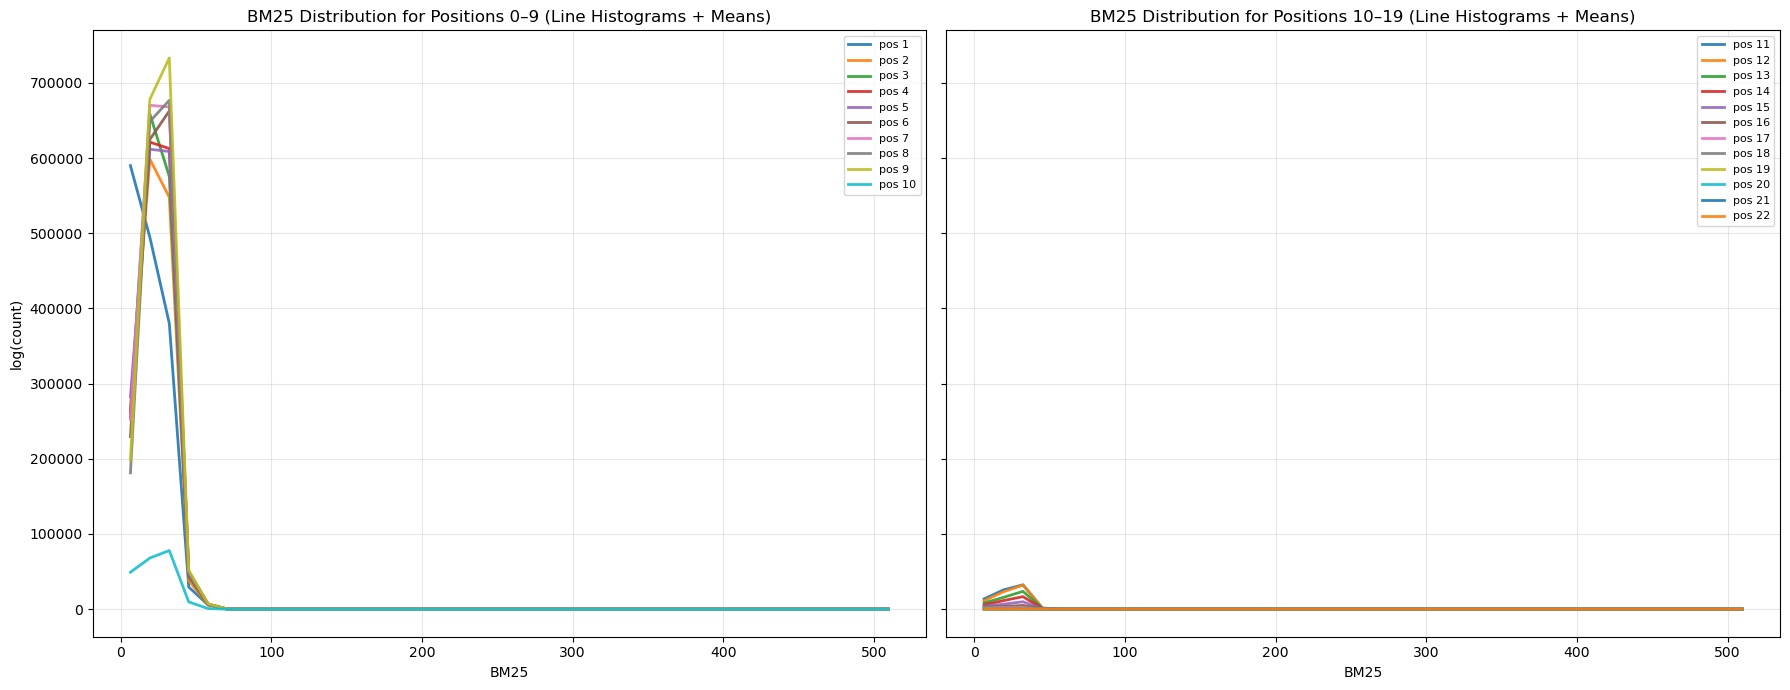

In [103]:
import numpy as np
import matplotlib.pyplot as plt

# Extract columns from pyarrow table as numpy
idf_arr = ltr_table["title_length"].to_numpy()
pos_arr = ltr_table["position"].to_numpy()

# ---- Step 1: Define positions ----
positions = np.sort(np.unique(pos_arr))

# ---- Step 2: Define histogram binning ----
num_bins = 40
idf_min, idf_max = idf_arr.min(), idf_arr.max()
bins = np.linspace(idf_min, idf_max, num_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# ---- Step 3: Compute histograms + means ----
histograms = {}
means = {}
for pos in positions:
    mask = pos_arr == pos
    idf_values = idf_arr[mask]

    counts, _ = np.histogram(idf_values, bins=bins)
    histograms[pos] = counts
    means[pos] = idf_values.mean()

# ---- Step 4: Split positions into two groups ----
left_positions  = positions[:10]
right_positions = positions[10:]

# ---- Step 5: Two-panel line-histogram plot + mean lines ----
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# ------ Left subplot ------
ax = axes[0]
for pos in left_positions:
    # Draw histogram line
    (line,) = ax.plot(
        bin_centers,
        histograms[pos],
        label=f"pos {pos}",
        linewidth=2,
        alpha=0.9,
    )


ax.set_title("BM25 Distribution for Positions 0–9 (Line Histograms + Means)")
ax.set_xlabel("BM25")
ax.set_ylabel("log(count)")
ax.grid(alpha=0.3)
ax.legend(ncol=1, fontsize=8)

# ------ Right subplot ------
ax = axes[1]
for pos in right_positions:
    # Draw histogram line
    (line,) = ax.plot(
        bin_centers,
        histograms[pos],
        label=f"pos {pos}",
        linewidth=2,
        alpha=0.9,
    )
    # Draw mean line


ax.set_title("BM25 Distribution for Positions 10–19 (Line Histograms + Means)")
ax.set_xlabel("BM25")
ax.grid(alpha=0.3)
ax.legend(ncol=1, fontsize=8)

plt.tight_layout()
plt.show()


Plotting: displayed_time


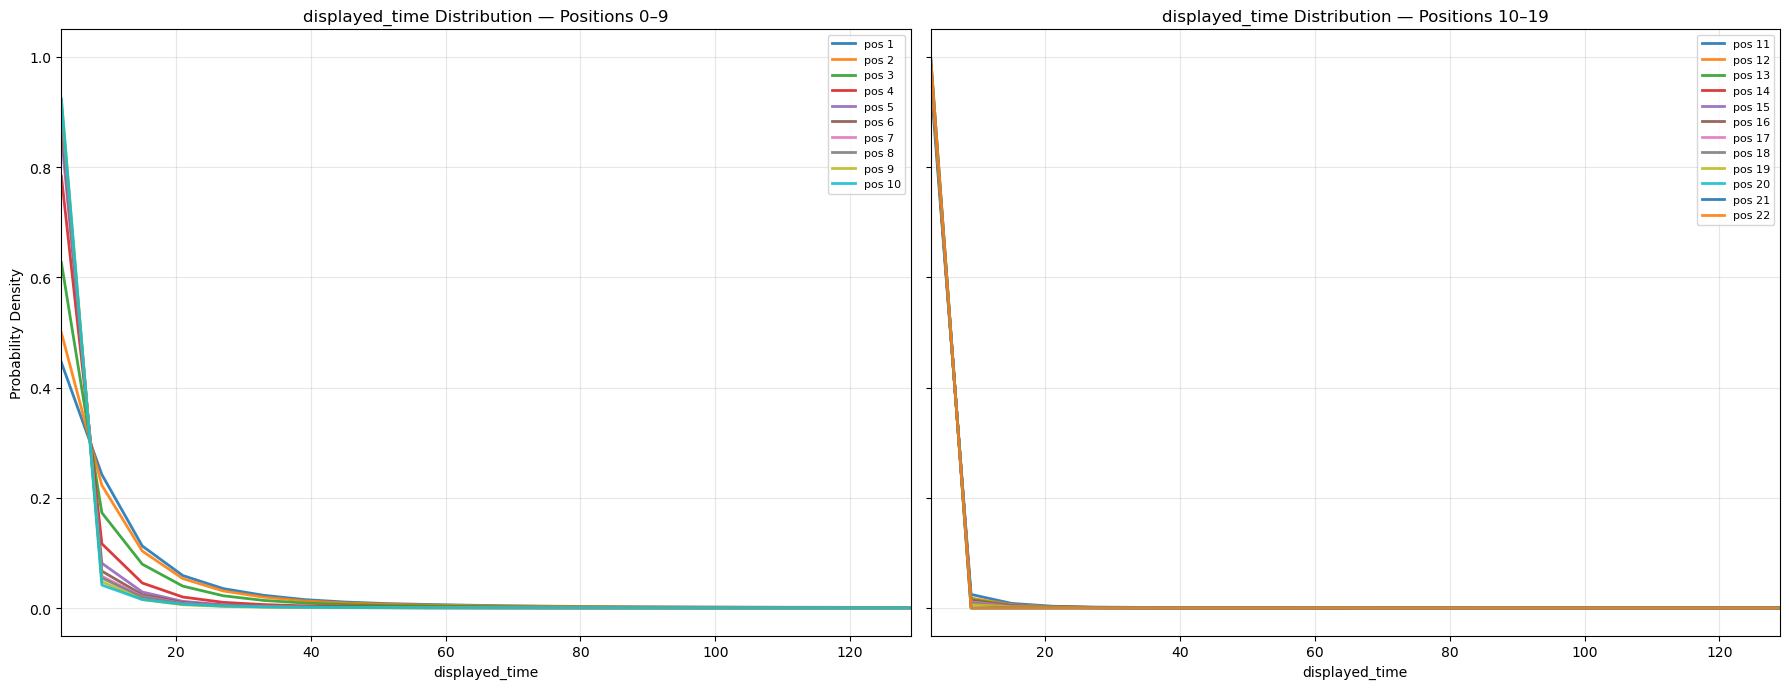

Plotting: serp_height


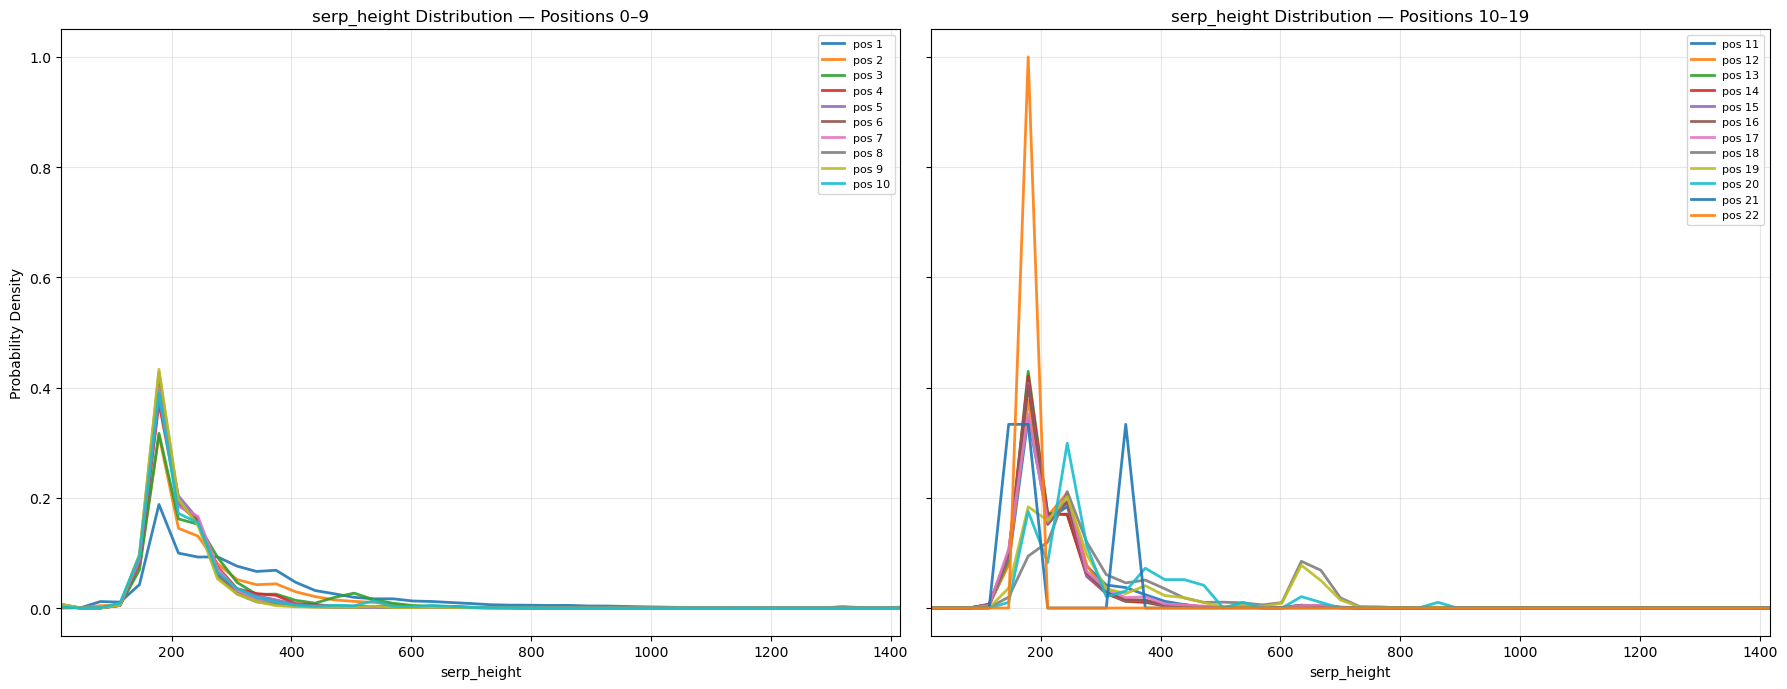

Plotting: slipoff_count_after_click


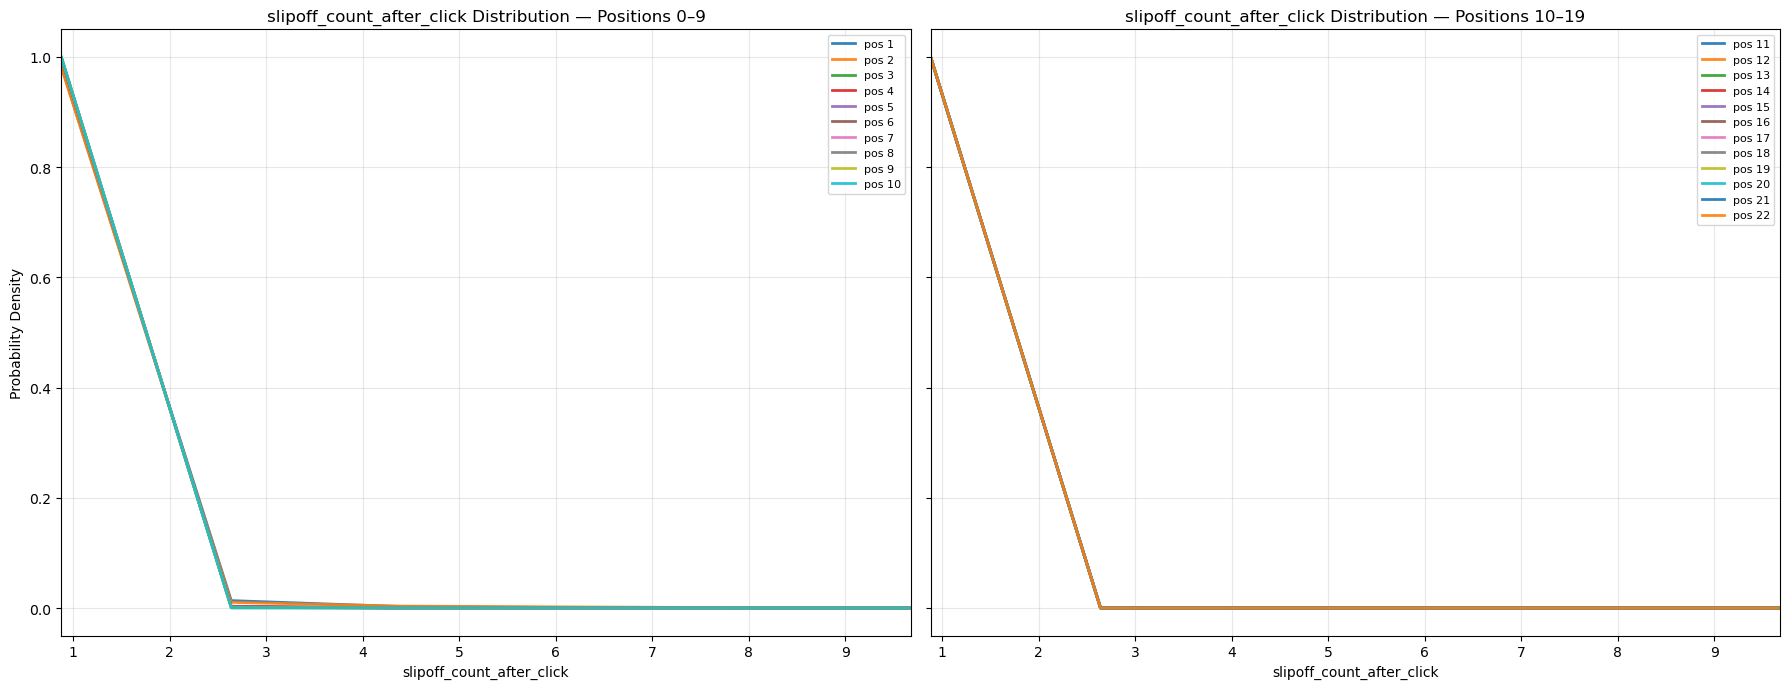

Plotting: click


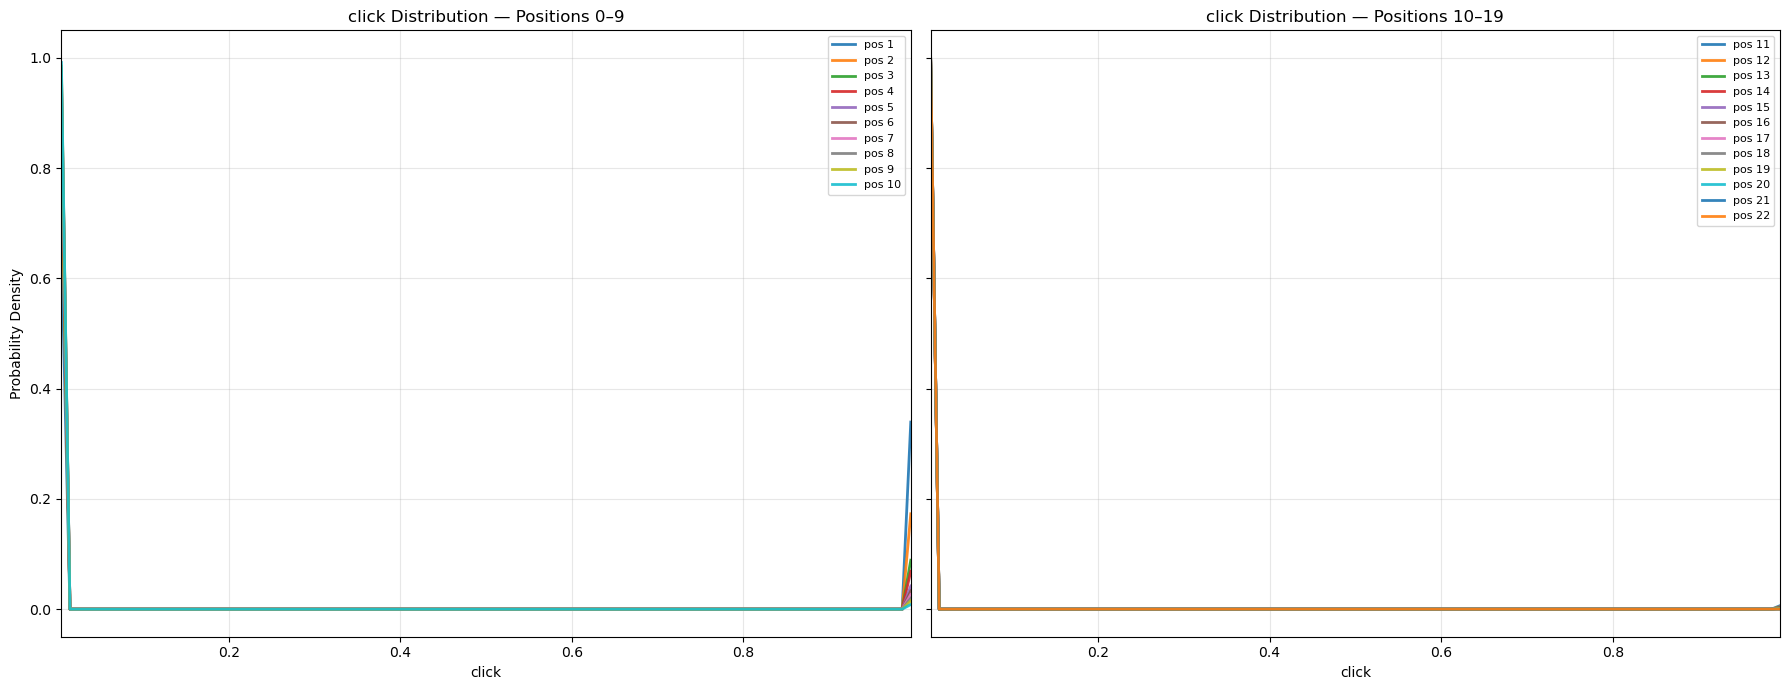

Plotting: bm25


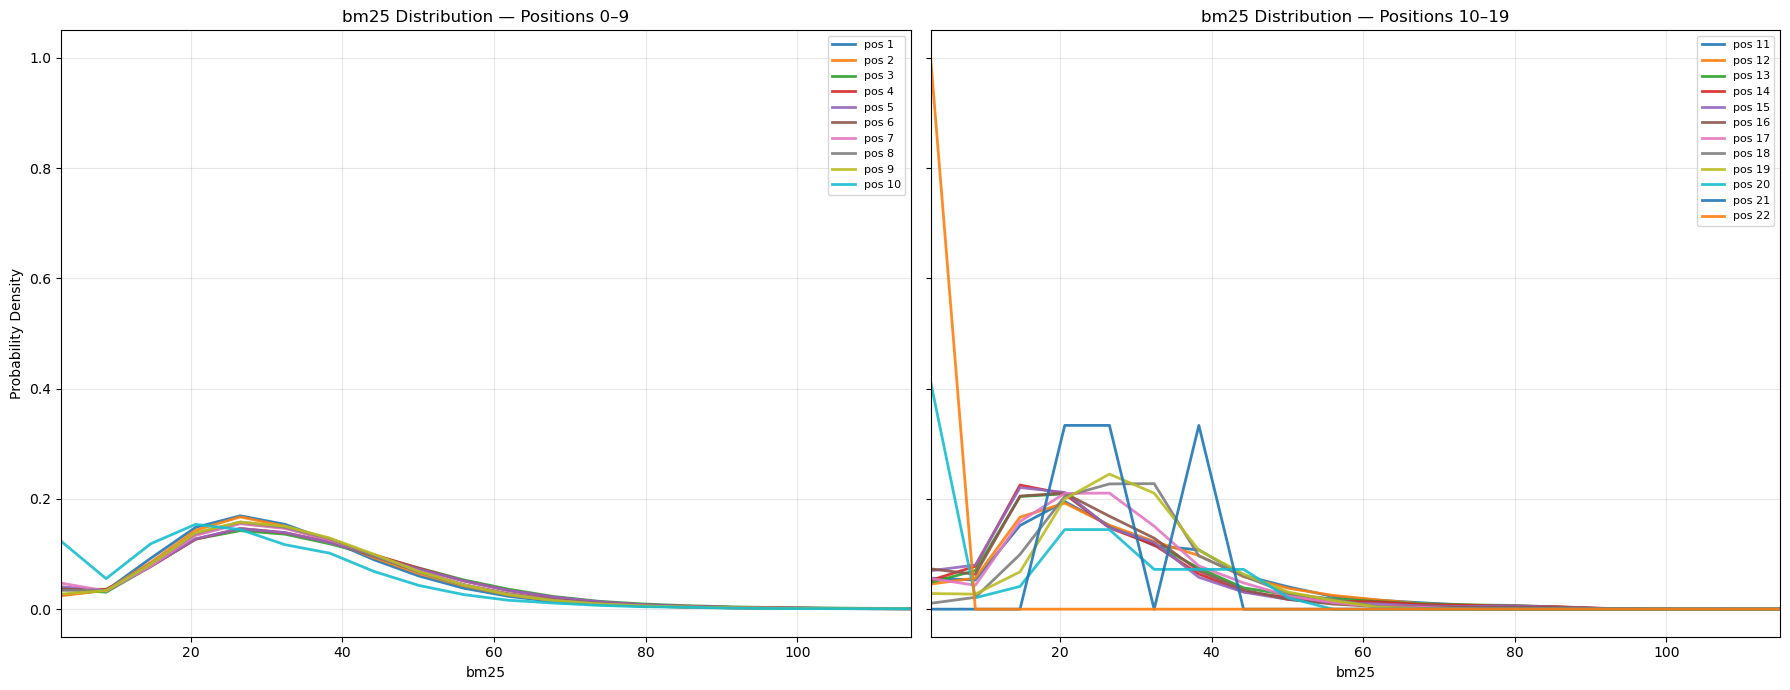

Plotting: bm25_title


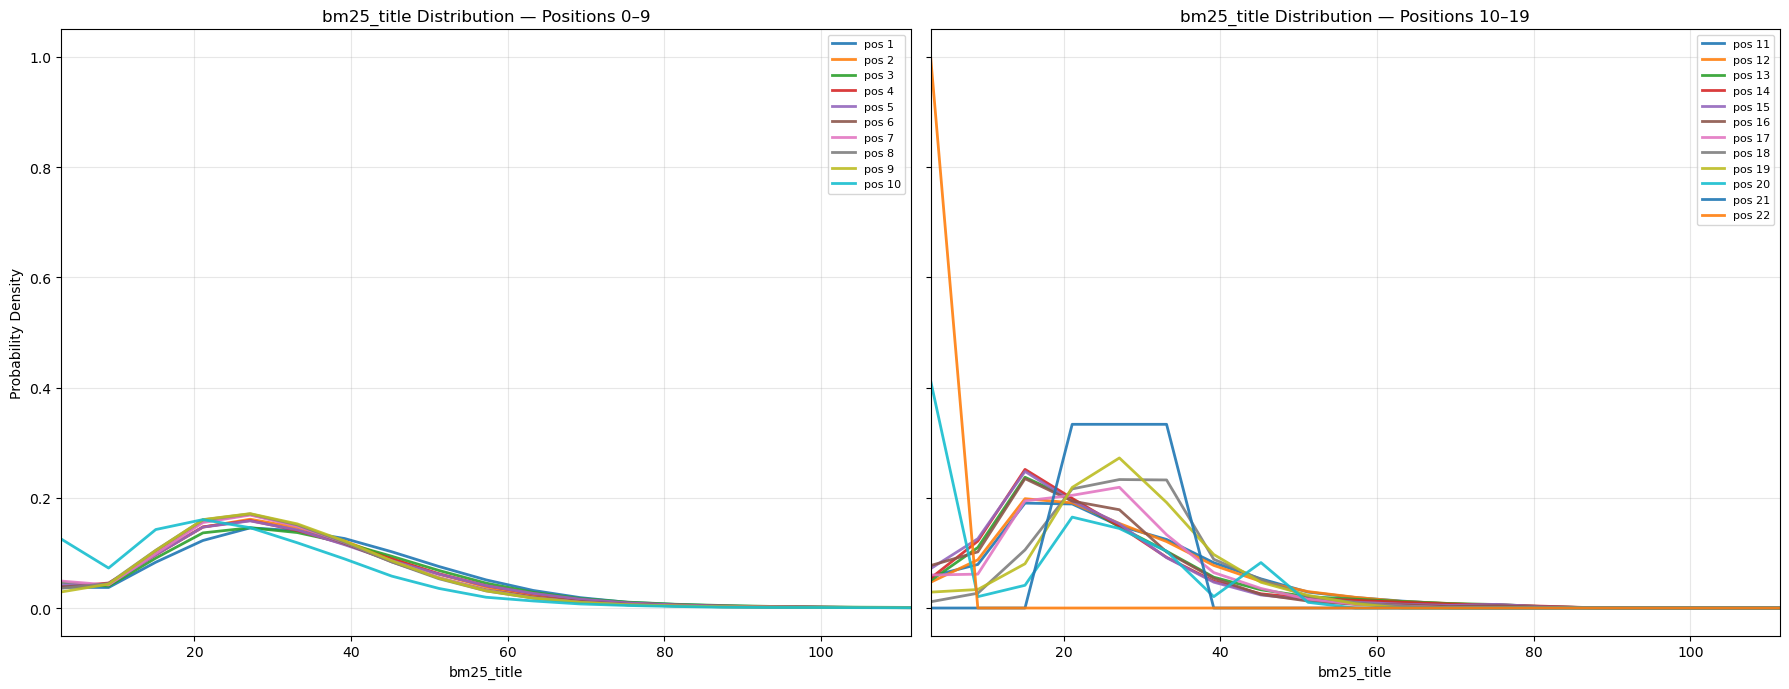

Plotting: bm25_abstract


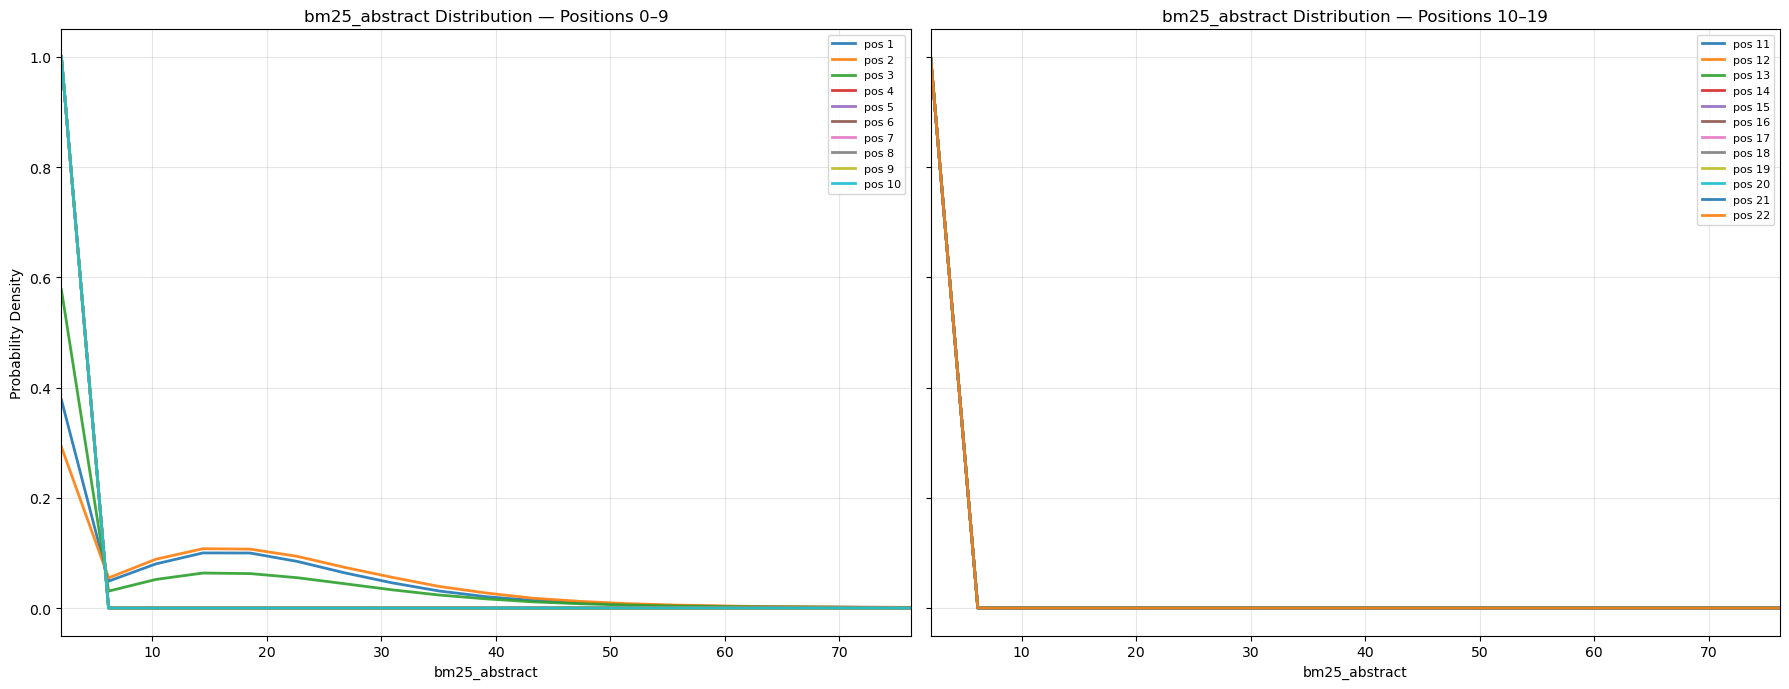

Plotting: tf_idf


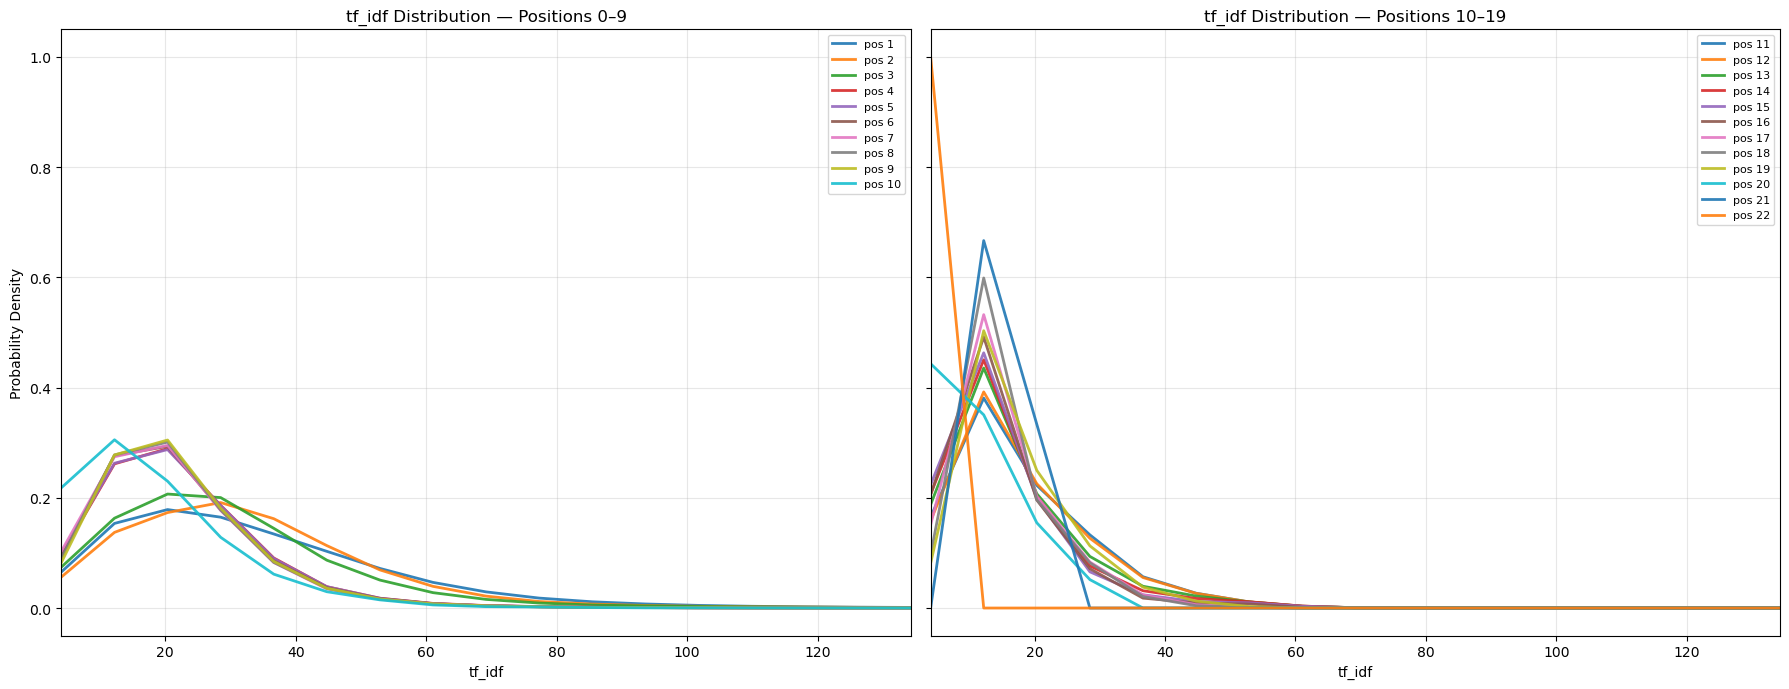

Plotting: tf


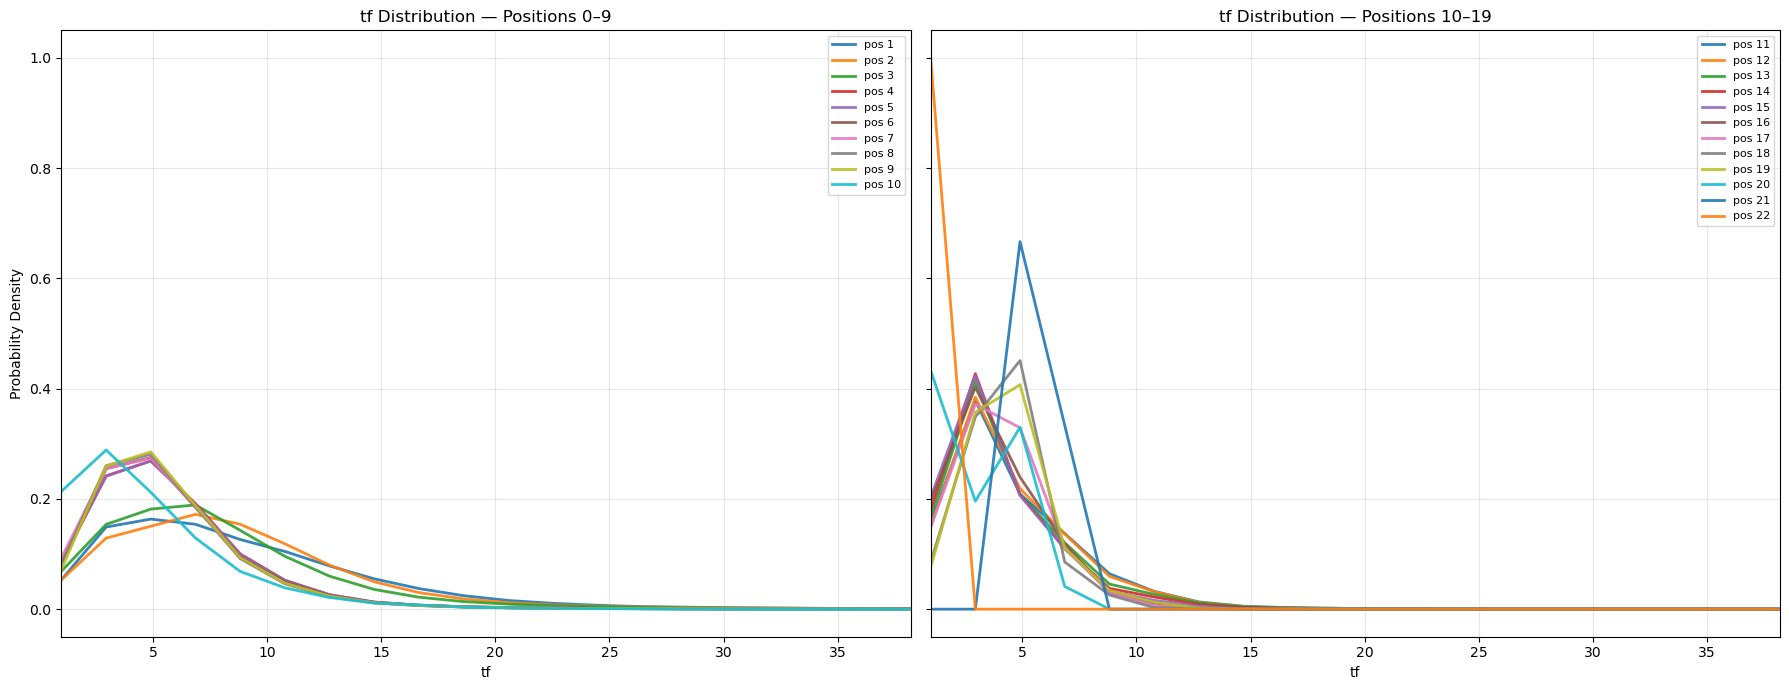

Plotting: idf


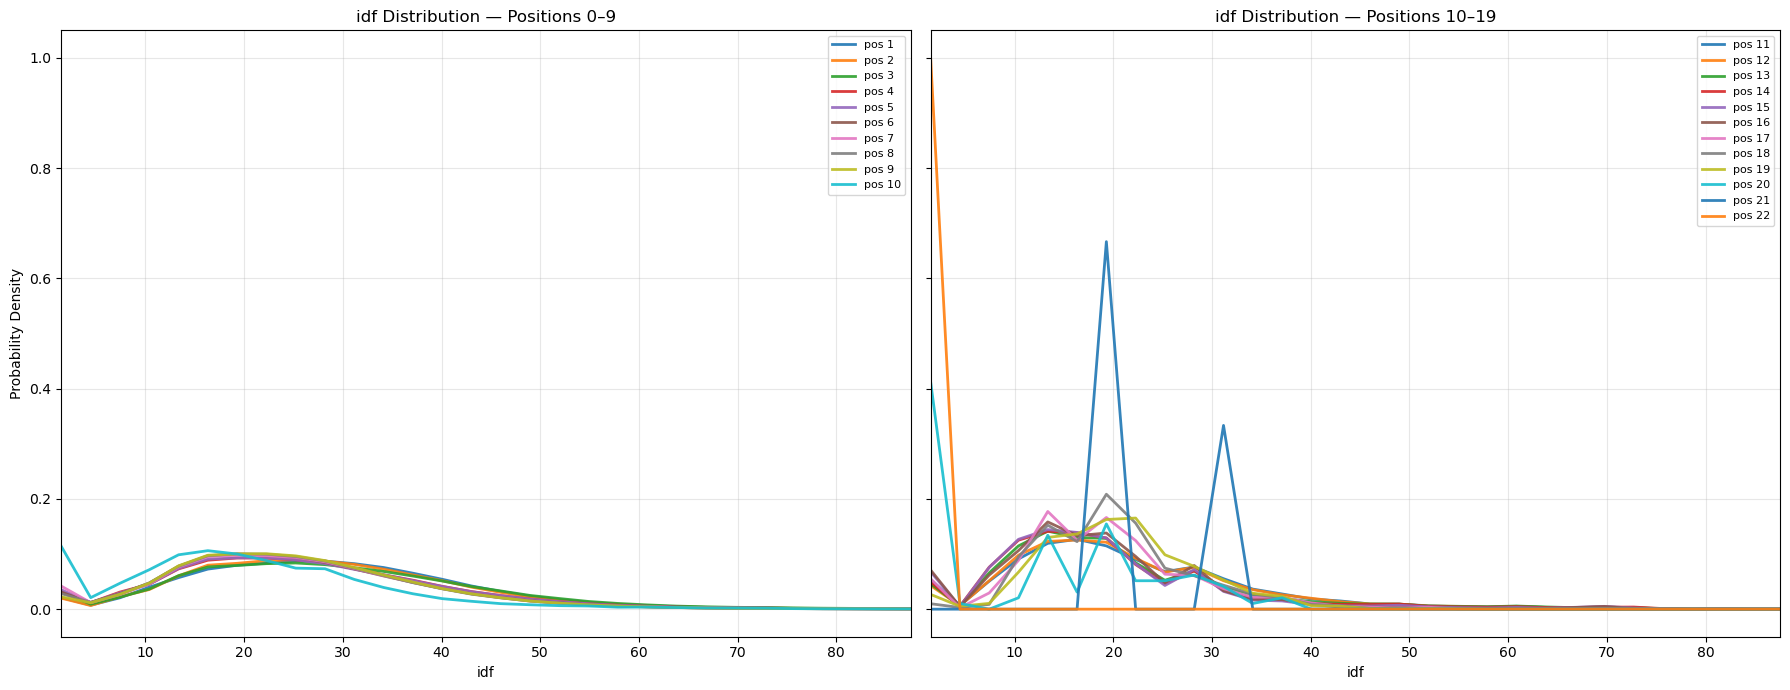

Plotting: ql_jelinek_mercer_short


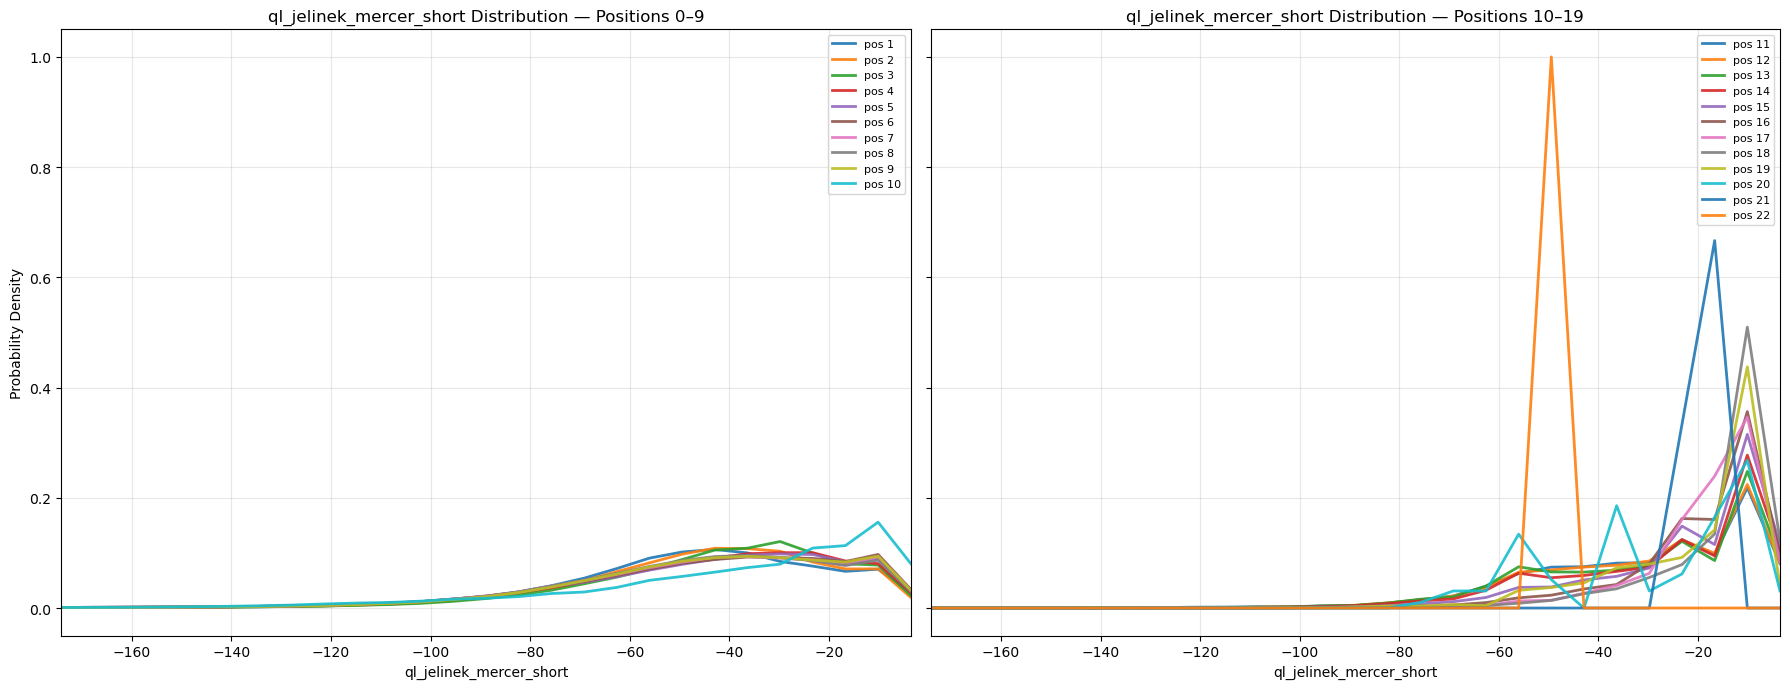

Plotting: ql_jelinek_mercer_long


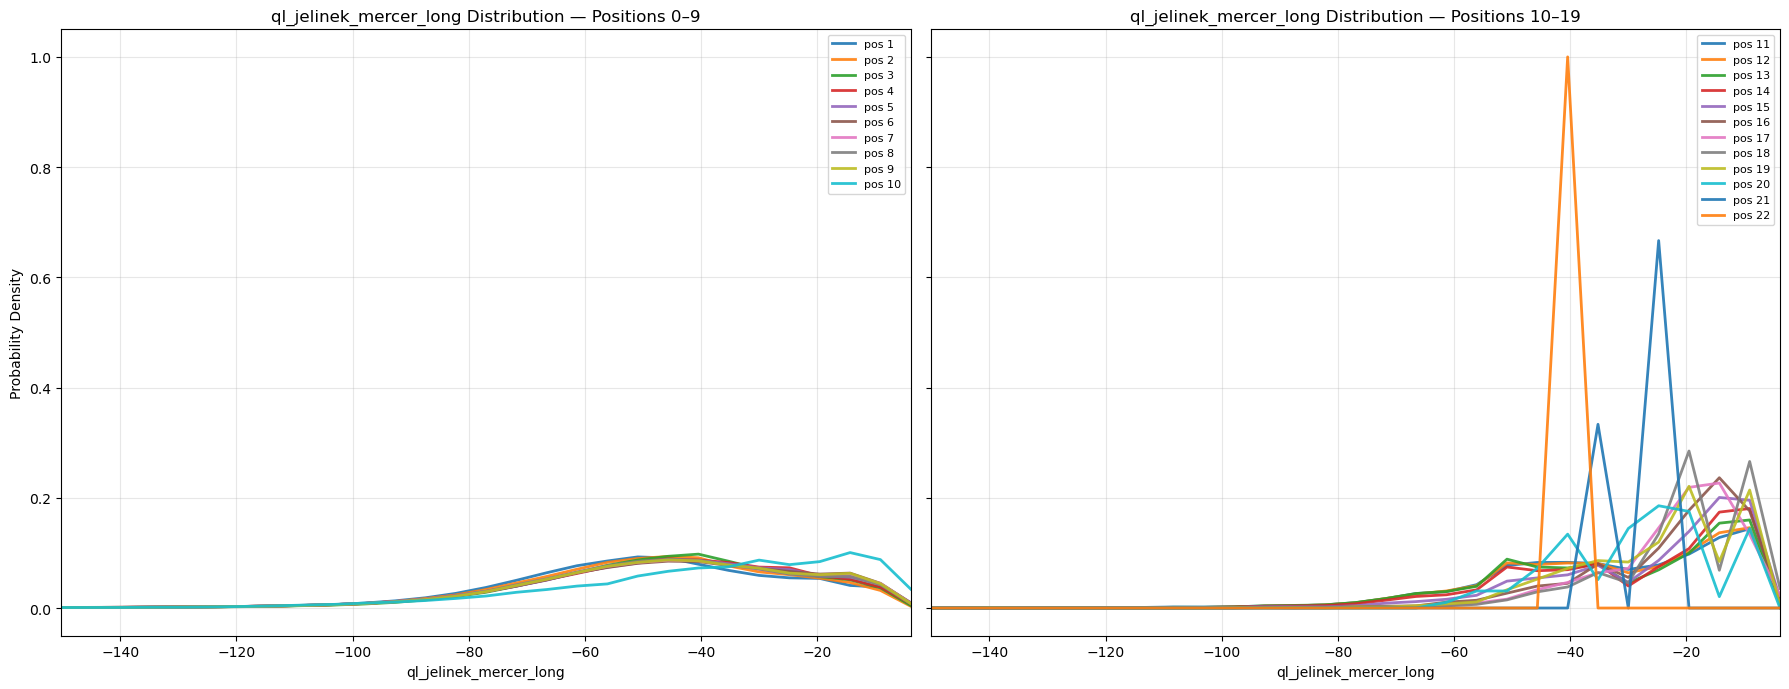

Plotting: ql_dirichlet


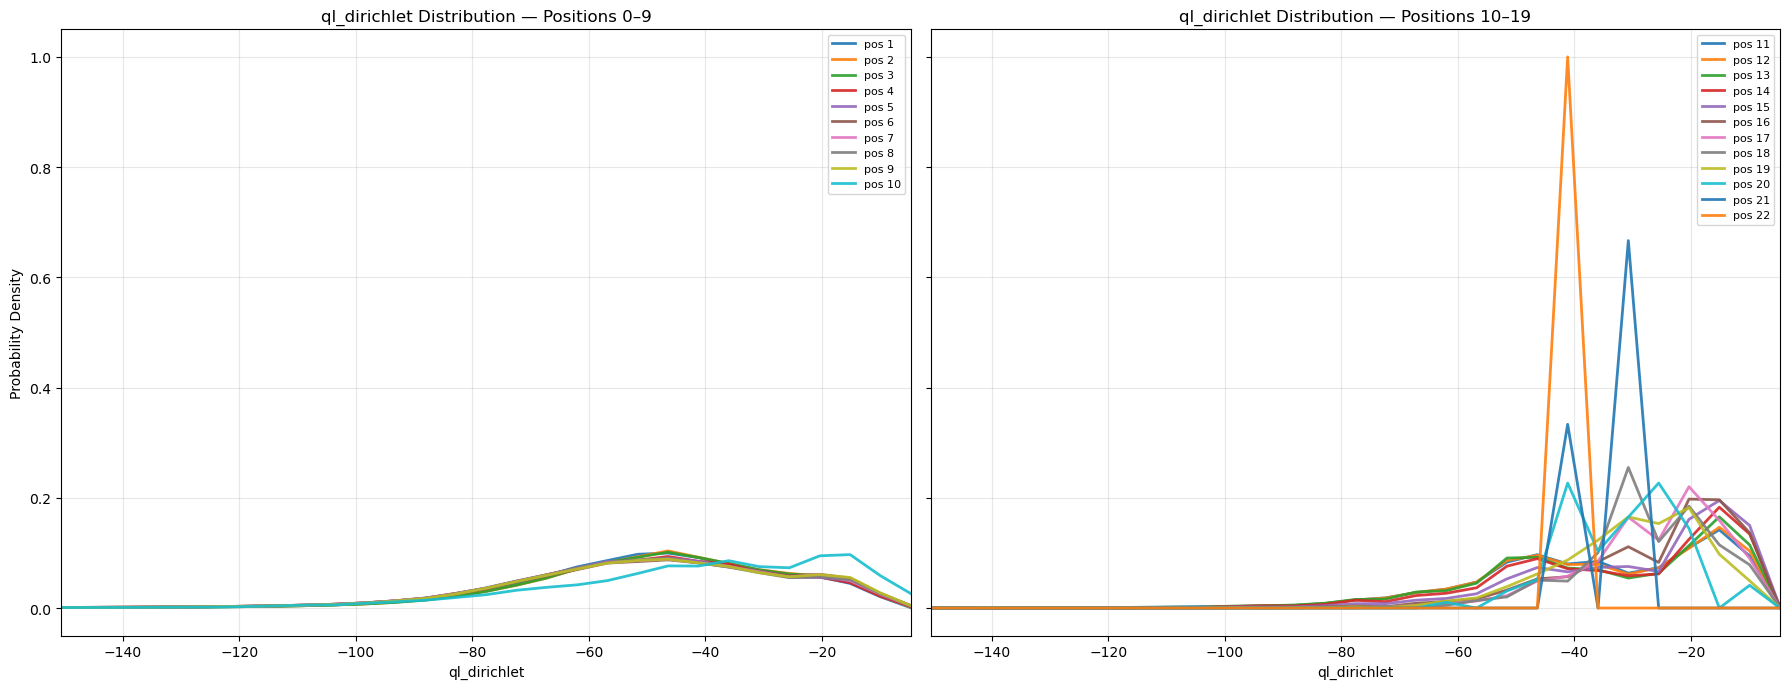

Plotting: query_length


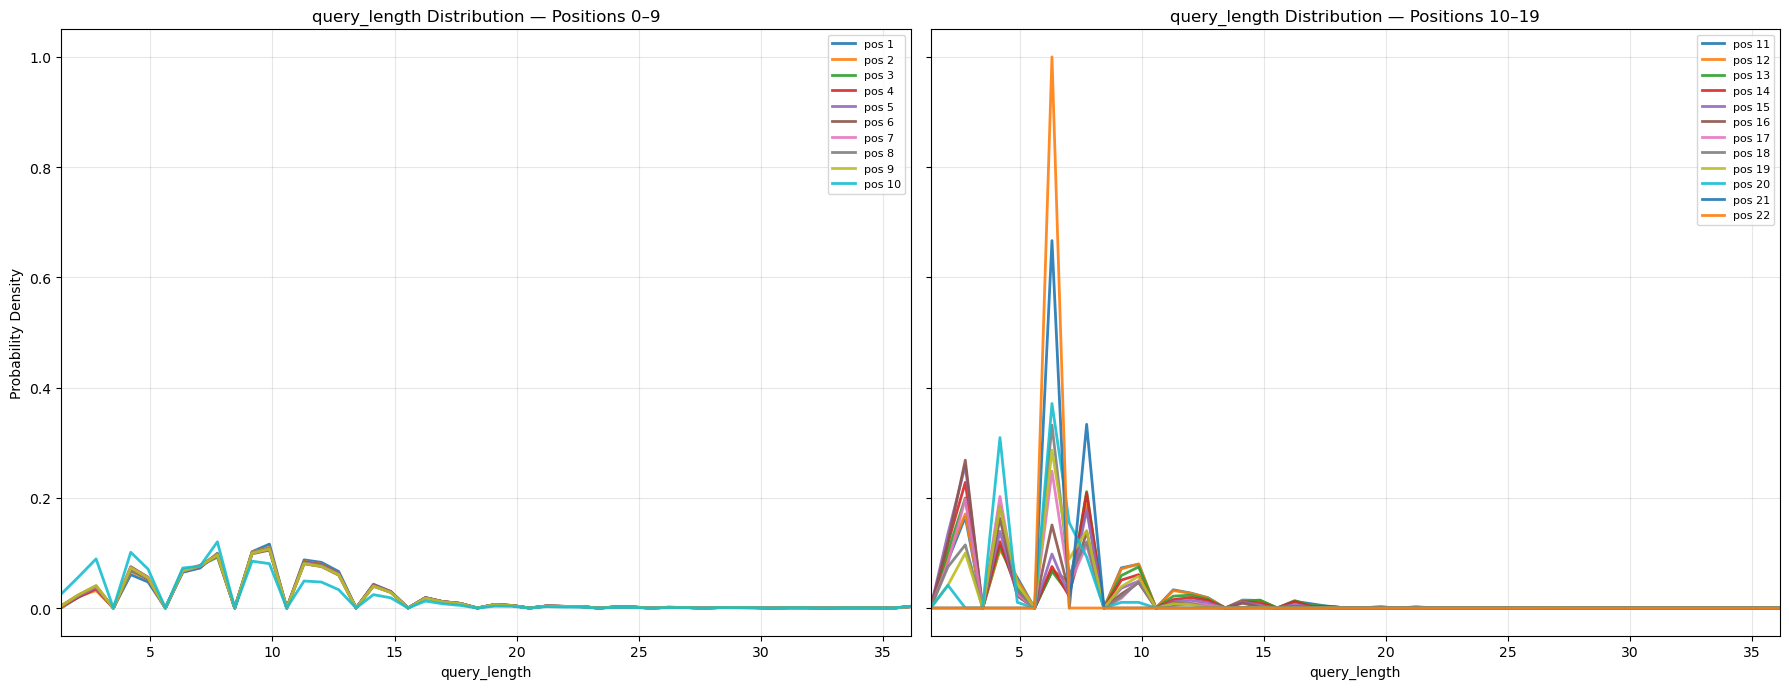

Plotting: document_length


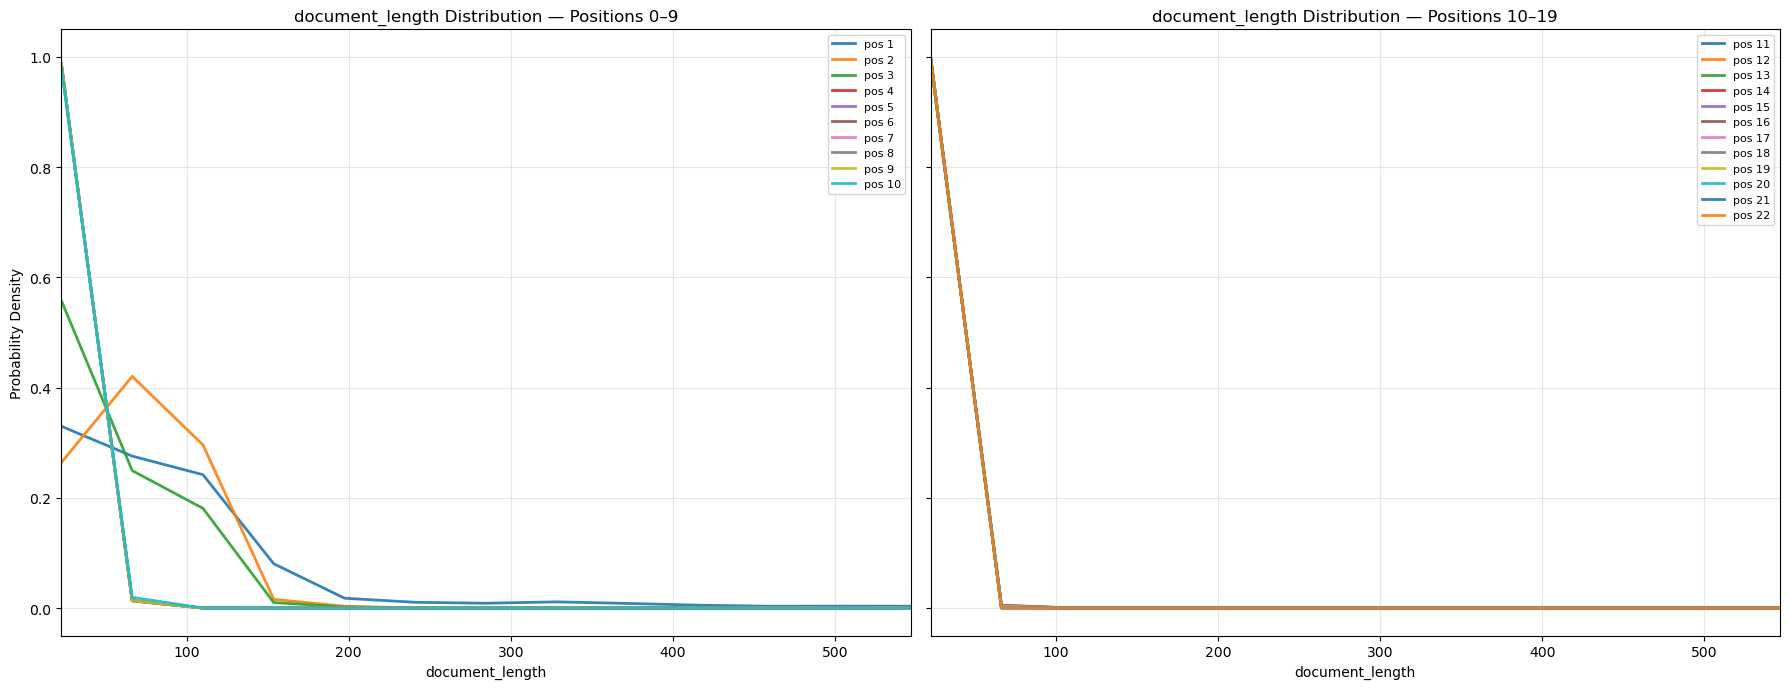

Plotting: title_length


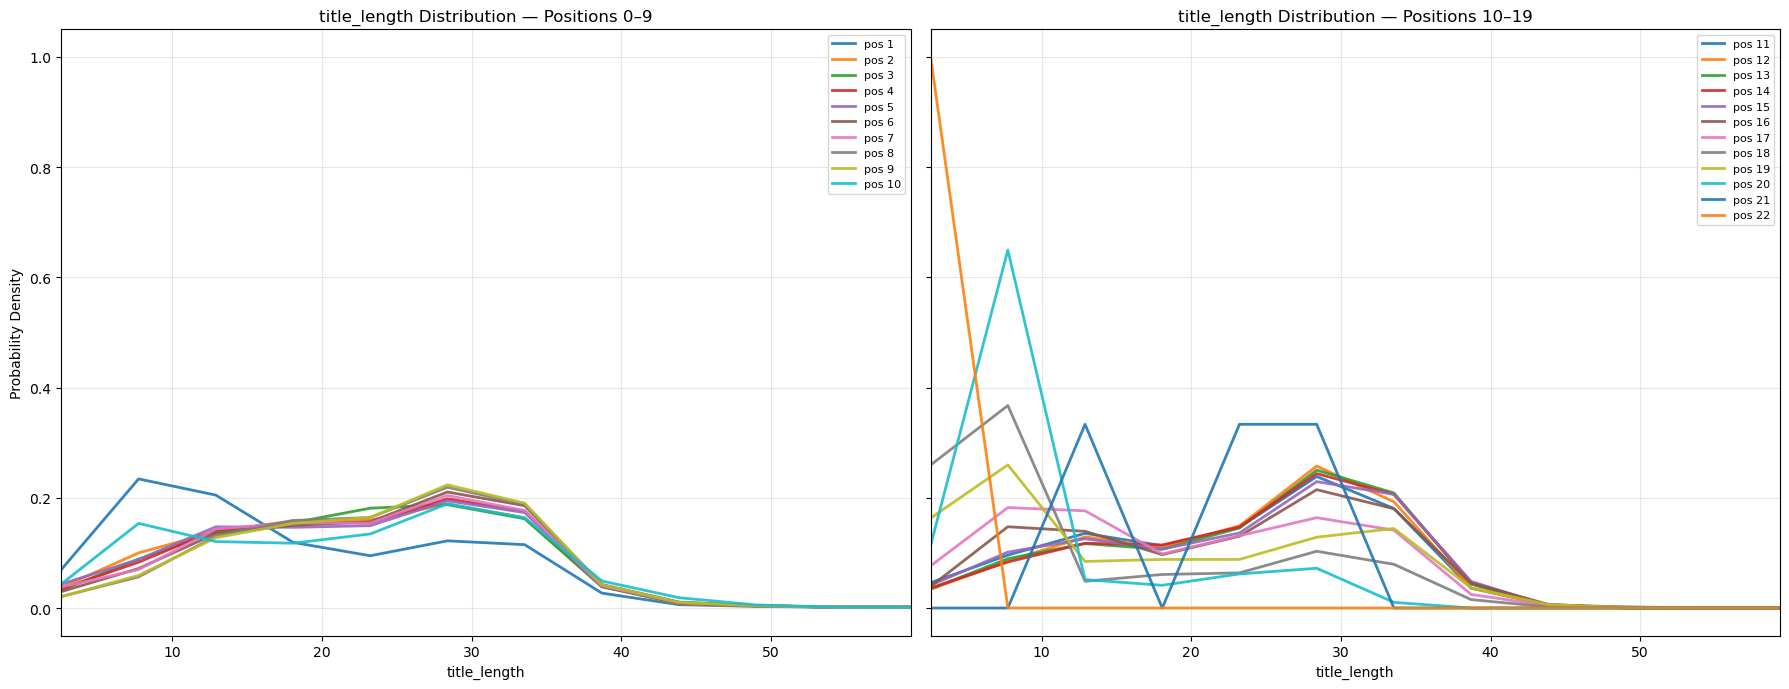

Plotting: abstract_length


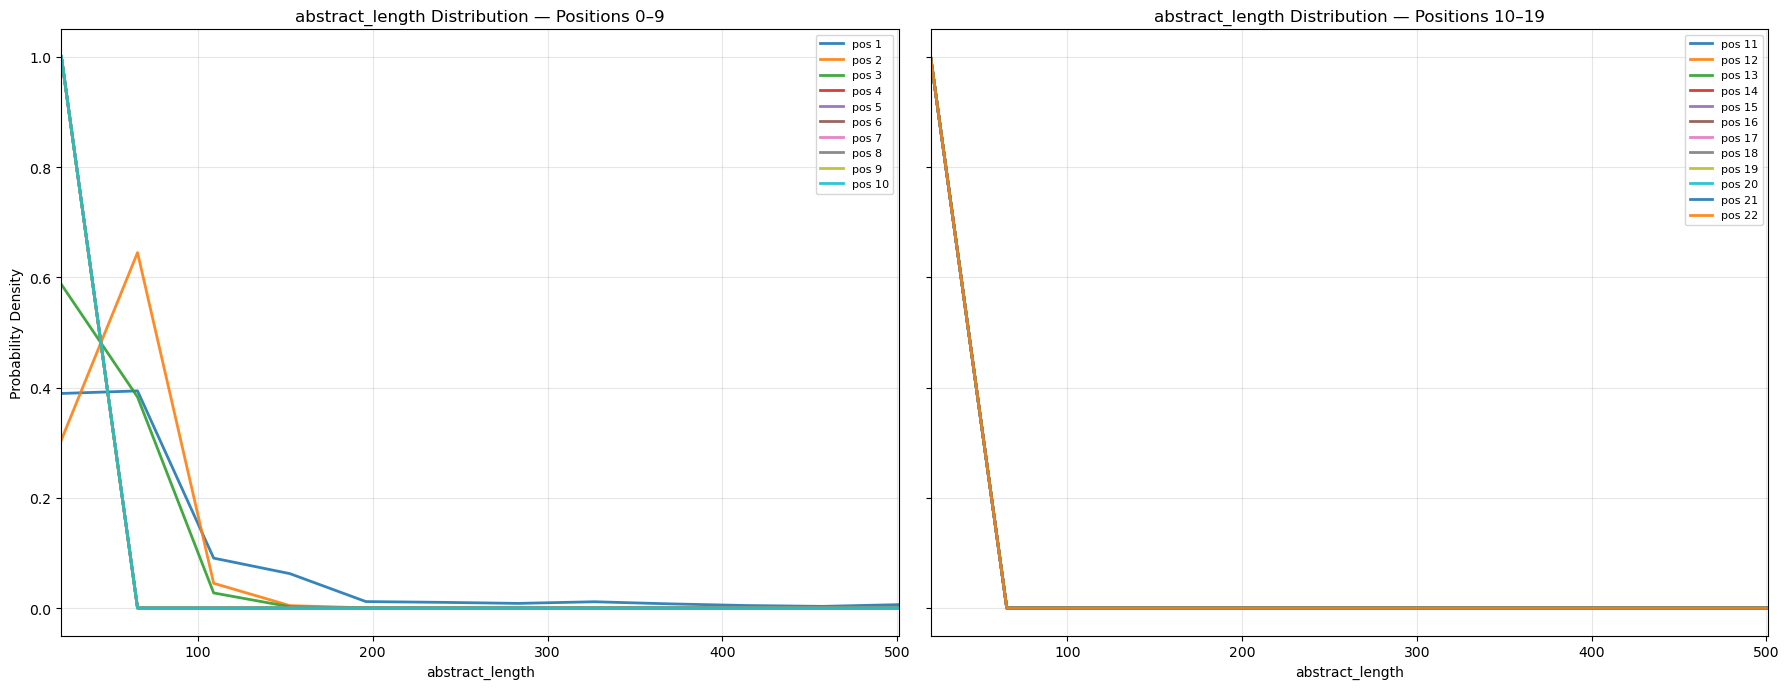

In [114]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

def plot_position_distributions(ltr_table, column_name, num_bins=100, tail_cut_threshold=0.001):
    """
    Plot normalized histograms per position for a given column from the LTR table,
    cutting off tails where probability is very low across all positions.
    
    tail_cut_threshold: minimum max probability to include a bin
    """
    # Extract arrays
    arr = ltr_table[column_name].to_numpy()
    pos_arr = ltr_table["position"].to_numpy()
    positions = np.sort(np.unique(pos_arr))

    # Define histogram binning
    vmin, vmax = arr.min(), arr.max()
    bins = np.linspace(vmin, vmax, num_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Compute normalized histograms
    histograms = {}
    for pos in positions:
        vals = arr[pos_arr == pos]
        counts, _ = np.histogram(vals, bins=bins)
        total = counts.sum()
        histograms[pos] = counts / total if total > 0 else counts

    # Determine x-axis range by cutting tails
    all_hist = np.array(list(histograms.values()))
    max_per_bin = all_hist.max(axis=0)
    valid_bins = max_per_bin > tail_cut_threshold
    x_min, x_max = bin_centers[valid_bins][0], bin_centers[valid_bins][-1]

    # Split into first 10 and next 10 positions
    left_positions  = positions[:10]
    right_positions = positions[10:]

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

    # ---- Left panel ----
    ax = axes[0]
    for pos in left_positions:
        ax.plot(
            bin_centers,
            histograms[pos],
            label=f"pos {pos}",
            linewidth=2,
            alpha=0.9
        )
    ax.set_title(f"{column_name} Distribution — Positions 0–9")
    ax.set_xlabel(column_name)
    ax.set_ylabel("Probability Density")
    ax.set_xlim(x_min, x_max)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

    # ---- Right panel ----
    ax = axes[1]
    for pos in right_positions:
        ax.plot(
            bin_centers,
            histograms[pos],
            label=f"pos {pos}",
            linewidth=2,
            alpha=0.9
        )
    ax.set_title(f"{column_name} Distribution — Positions 10–19")
    ax.set_xlabel(column_name)
    ax.set_xlim(x_min, x_max)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


features = [
    "displayed_time",
    "serp_height",
    "slipoff_count_after_click",
    "click",
    "bm25",
    "bm25_title",
    "bm25_abstract",
    "tf_idf",
    "tf",
    "idf",
    "ql_jelinek_mercer_short",
    "ql_jelinek_mercer_long",
    "ql_dirichlet",
    "query_length",
    "document_length",
    "title_length",
    "abstract_length"
]

for feat in features:
    print("Plotting:", feat)
    plot_position_distributions(ltr_table, feat)
